# Pipeline v5 — MBM vs MBM+LSTM vs MBM+MLP (Finf(t), k′(t) dinâmicos)

Este notebook implementa:
- **MBM baseline** (Finf e k′ constantes) com **bootstrap por blocos** (block_size=6)
- **Híbridos físicos-informados**: a rede estima **Finf(t)** e **k′(t)** e a **equação MBM é a camada de saída**
- Duas redes (comparação justa): **LSTM** vs **MLP** (mesma janela `seq_len=6`, MLP usa flatten)
- Pré-processamento: **outliers de Cout substituídos pela média local** + **censura de Cin** (remoção de eventos internos)
- Avaliação: Nested TimeSeriesSplit, ΔRMSE/ΔR² por bootstrap em TESTE, **Diebold–Mariano**, e análise física (Spearman + lags)

⚙️ Config padrão conforme solicitado: `seq_len=6`, `block_size=6`, bootstrap moderado `n_boot=200`.


In [15]:

# =========================
# 0) Imports e Config
# =========================
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

from scipy.stats import spearmanr


In [16]:

# =========================
# 1) CONFIG (AJUSTE AQUI)
# =========================

FILES = {
    #"R1": "casa1PM.xlsx",
    "R2": "casa2PM.xlsx",
    "R3": "casa3PM.xlsx",
    #"R4": "casa4PM.xlsx",
    #"R5": "pairIC1PM_trimestre.xlsx",
    #"R6": "pairIC4PM_trimestre.xlsx",
    #"R7": "pairIC5PM_trimestre.xlsx",
}

PM_FRACTIONS = {
    "MP1":   ("cinPM1",  "coutPM1"),
    "MP2.5": ("cinPM25", "coutPM25"),
    "MP10":  ("cinPM10", "coutPM10"),
}

HOUR_COL = "hora"
DAY_COL  = "dia"

EXTRA_COLS = ["URout","wd","ws"]  # use as colunas que existirem

DT = 1.0
SEQ_LEN = 6
BLOCK_SIZE = 6

OUTER_SPLITS = 3
INNER_SPLITS = 2
N_TRIALS = 12   # random search por arquitetura (aumente para 20+ se quiser)


# Bootstrap (moderado, conforme você escolheu)
BOOT_PARAM = 200          # IC de Finf(t), k(t), Cin_hat(t) via bootstrap por blocos (re-treino)
BOOT_TEST  = 200         # ΔRMSE/ΔR² no teste (barato, não re-treina rede)
BLOCK_SIZE_TEST = 12      # bloco maior no teste (tende a ser mais conservador), ajuste se quiser 6

TEST_FRAC = 0.25          # fração final para teste (apenas para gráficos e comparações estatísticas)
SEED = 123

DETAILS_SHAPED = {}  # para guardar detalhes de SHAP (modelo, X_s, feat_names) para cada casa e poluente

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cpu


In [17]:

# =========================
# 2) Utilidades: tempo/hora, outliers, censura
# =========================

def convert_hour_to_decimal(df: pd.DataFrame, hour_col: str = "hora") -> pd.DataFrame:
    """Converte 'hora' em decimal (aceita datetime.time, string, numérico)."""
    if hour_col not in df.columns:
        return df

    def _to_decimal(x):
        if pd.isna(x):
            return np.nan
        if hasattr(x, "hour"):
            return x.hour + x.minute/60 + x.second/3600
        if isinstance(x, str):
            try:
                t = pd.to_datetime(x).time()
                return t.hour + t.minute/60 + t.second/3600
            except Exception:
                return np.nan
        try:
            return float(x)
        except Exception:
            return np.nan

    df = df.copy()
    df[hour_col] = df[hour_col].apply(_to_decimal)
    return df


def add_time_features(df: pd.DataFrame, hour_col: Optional[str]) -> pd.DataFrame:
    """Adiciona hour_sin/cos se hour_col existir e tiver valores válidos."""
    df = df.copy()
    if hour_col is None or hour_col not in df.columns:
        return df
    h = df[hour_col].astype(float).values
    df["hour_sin"] = np.sin(2*np.pi*h/24.0)
    df["hour_cos"] = np.cos(2*np.pi*h/24.0)
    return df


def replace_outliers_cout_local_mean(cout: np.ndarray, window: int = 3, z: float = 3.5) -> np.ndarray:
    """
    Substitui outliers em Cout por média local.
    Detecta outliers via desvio robusto (mediana + MAD) em janela móvel.
    """
    cout = np.asarray(cout, float).copy()
    s = pd.Series(cout)

    med = s.rolling(window*2+1, center=True, min_periods=1).median()
    mad = (s - med).abs().rolling(window*2+1, center=True, min_periods=1).median()
    mad = mad.replace(0, np.nan)
    zscore = ((s - med).abs()) / (1.4826 * mad)

    out = (zscore > z).fillna(False).values
    idxs = np.where(out)[0]

    for i in idxs:
        lo = max(0, i-window)
        hi = min(len(cout), i+window+1)
        local = cout[lo:hi]
        local = local[np.isfinite(local)]
        if len(local) > 0:
            cout[i] = float(np.mean(local))

    return cout


def censor_internal_events(cin: np.ndarray, cout: np.ndarray, threshold_ratio: float = 1.2):
    """
    Censura (remove) pontos com forte indício de origem interna:
    marca como "externo" quando cout >= cin/threshold_ratio.
    Retorna cin_censurado (NaN nos internos) e mask_external.
    """
    cin = np.asarray(cin, float).copy()
    cout = np.asarray(cout, float)
    
    # Cin_prev
    cin_prev = np.roll(cin, 1)
    cin_prev[0] = cin[0]

    mask_external = (cin / cout) < threshold_ratio
    mask_external = mask_external | (cin < 1.75*cin_prev)
    cin_cens = cin.copy()
    cin_cens[~mask_external] = np.nan

    return cin_cens, mask_external


In [18]:

# =========================
# 3) Features (iguais para LSTM/MLP)
# =========================

def build_features(df: pd.DataFrame, cout_col: str, extra_cols: Optional[List[str]], hour_col: Optional[str]) -> Tuple[np.ndarray, List[str]]:
    """
    Retorna X(t) com colunas:
      - Cout
      - extras (se existirem)
      - hour_sin, hour_cos (se disponíveis)
    OBS: Cin_prev entra no dataset (para MBM), não aqui.
    """
    cols = []
    names = []

    cols.append(df[cout_col].astype(float).values.reshape(-1,1))
    names.append("Cout")

    if extra_cols:
        for c in extra_cols:
            if c in df.columns:
                cols.append(df[c].astype(float).values.reshape(-1,1))
                names.append(c)

    # hora cíclica
    if hour_col is not None and "hour_sin" in df.columns and "hour_cos" in df.columns:
        cols.append(df["hour_sin"].astype(float).values.reshape(-1,1)); names.append("hour_sin")
        cols.append(df["hour_cos"].astype(float).values.reshape(-1,1)); names.append("hour_cos")

    X = np.hstack(cols)
    return X, names


def standardize_train_apply(X_train: np.ndarray, X_apply: np.ndarray):
    mu = np.nanmean(X_train, axis=0)
    sd = np.nanstd(X_train, axis=0)
    sd[sd==0] = 1.0
    return (X_train-mu)/sd, (X_apply-mu)/sd, mu, sd


In [19]:

# =========================
# 4) MBM baseline (Finf e k' constantes) + bootstrap por blocos
# =========================

def estimate_params_linear(cin: np.ndarray, cout: np.ndarray, dt: float = 1.0) -> Tuple[float, float]:
    """
    Ajuste linear para MBM discreto:
      cin(t) = a*cin(t-1) + b*cout(t)
    então:
      k = -ln(a)/dt, Finf = b/(1-a)
    """
    cin = np.asarray(cin, float)
    cout = np.asarray(cout, float)

    cin_t = cin[:-1]
    cout_t = cout[1:]  # cout(t) alinhado ao cin(t)
    y = cin[1:]

    X = np.column_stack([cin_t, cout_t])

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    a, b = beta

    if not (0 < a < 0.999):
        return np.nan, np.nan

    k = -np.log(a)/dt
    Finf = b/(1-a)

    if not (np.isfinite(k) and np.isfinite(Finf)):
        return np.nan, np.nan

    return float(np.clip(Finf, 0, 1)), float(np.clip(k, 0, None))


def block_bootstrap_indices(T: int, block_size: int, rng: np.random.Generator) -> np.ndarray:
    idx=[]
    while len(idx) < T:
        start = int(rng.integers(0, T - block_size + 1))
        idx.extend(range(start, start + block_size))
    return np.array(idx[:T], dtype=int)


def mbm_reconstruct_constant(cin: np.ndarray, cout: np.ndarray, Finf: float, k: float, dt: float = 1.0) -> np.ndarray:
    cin = np.asarray(cin, float)
    cout = np.asarray(cout, float)
    T = len(cin)
    out = np.full(T, np.nan)
    out[0] = cin[0]
    for t in range(1, T):
        if not (np.isfinite(cin[t-1]) and np.isfinite(cout[t])):
            continue
        decay = np.exp(-k*dt)
        out[t] = cin[t-1]*decay + Finf*cout[t]*(1-decay)
    return out


def mbm_with_uncertainty(cin: np.ndarray, cout: np.ndarray, mask_external: np.ndarray,
                         block_size: int = 6, n_boot: int = 200, dt: float = 1.0, seed: int = 123):
    """
    Estima Finf, k' a partir de pontos externos (cin censurado) e gera IC via bootstrap por blocos.
    Também propaga para Cin_hat(t) (IC95%).
    """
    rng = np.random.default_rng(seed)

    cin = np.asarray(cin, float)
    cout = np.asarray(cout, float)
    mask_external = np.asarray(mask_external, bool)

    # usa apenas pontos externos e finitos para ajuste de parâmetros
    valid = mask_external & np.isfinite(cin) & np.isfinite(cout)
    cin_ext = cin[valid]
    cout_ext = cout[valid]

    if len(cin_ext) < 10:
        # fallback: usa tudo
        cin_ext = cin[np.isfinite(cin) & np.isfinite(cout)]
        cout_ext = cout[np.isfinite(cin) & np.isfinite(cout)]

    Finf0, k0 = estimate_params_linear(cin_ext, cout_ext, dt=dt)

    Finf_s = []
    k_s = []
    cin_hat_s = []

    for b in range(n_boot):
        idx = block_bootstrap_indices(len(cin_ext), block_size, rng)
        Finf_b, k_b = estimate_params_linear(cin_ext[idx], cout_ext[idx], dt=dt)
        if np.isfinite(Finf_b) and np.isfinite(k_b):
            Finf_s.append(Finf_b)
            k_s.append(k_b)
            cin_hat_s.append(mbm_reconstruct_constant(cin, cout, Finf_b, k_b, dt=dt))

    Finf_s = np.array(Finf_s, float)
    k_s = np.array(k_s, float)
    cin_hat_s = np.array(cin_hat_s, float) if len(cin_hat_s) else None

    def pct(a):
        return np.nanpercentile(a, [2.5, 97.5])

    Finf_ci = pct(Finf_s) if len(Finf_s) else (np.nan, np.nan)
    k_ci = pct(k_s) if len(k_s) else (np.nan, np.nan)

    cin_hat = mbm_reconstruct_constant(cin, cout, float(np.nanmean(Finf_s)) if len(Finf_s) else Finf0,
                                       float(np.nanmean(k_s)) if len(k_s) else k0, dt=dt)

    cin_lo = np.nanpercentile(cin_hat_s, 2.5, axis=0) if cin_hat_s is not None else None
    cin_hi = np.nanpercentile(cin_hat_s, 97.5, axis=0) if cin_hat_s is not None else None

    return dict(
        Finf=float(np.nanmean(Finf_s)) if len(Finf_s) else Finf0,
        k=float(np.nanmean(k_s)) if len(k_s) else k0,
        Finf_ci=Finf_ci,
        k_ci=k_ci,
        cin_hat=cin_hat,
        cin_hat_lo=cin_lo,
        cin_hat_hi=cin_hi,
        Finf_samples=Finf_s,
        k_samples=k_s
    )


In [20]:

# =========================
# 5) Dataset + Modelos híbridos (Finf(t), k(t) -> MBM)
# =========================

class SeqDatasetMBM(Dataset):
    """
    Amostra i retorna:
      x_seq: (seq_len, n_features) com features até t-1
      cin_prev: Cin(t-1)
      cout_t: Cout(t)
      cin_t: Cin(t) alvo
    """
    def __init__(self, X, cin, cout, seq_len=6):
        self.X = np.asarray(X, float)
        self.cin = np.asarray(cin, float)
        self.cout = np.asarray(cout, float)
        self.seq_len = int(seq_len)

    def __len__(self):
        return max(0, len(self.X) - self.seq_len)

    def __getitem__(self, idx):
        t = idx + self.seq_len
        x_seq = self.X[t-self.seq_len:t]
        return (
            torch.tensor(x_seq, dtype=torch.float32),
            torch.tensor(self.cin[t-1], dtype=torch.float32),
            torch.tensor(self.cout[t], dtype=torch.float32),
            torch.tensor(self.cin[t], dtype=torch.float32),
        )


def mbm_step_torch(cin_prev, cout_t, Finf_t, k_t, dt=1.0):
    decay = torch.exp(-k_t * dt)
    return cin_prev * decay + Finf_t * cout_t * (1.0 - decay)


class LSTM_MBM(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden, 2)

    def forward(self, x_seq):
        out, _ = self.lstm(x_seq)
        h = out[:, -1, :]
        params = self.fc(h)
        Finf = torch.sigmoid(params[:, 0])
        k = F.softplus(params[:, 1])
        return Finf, k


class MLP_MBM(nn.Module):
    def __init__(self, n_features, seq_len=6, hidden_sizes=(128,64), dropout=0.1):
        super().__init__()
        in_dim = int(n_features) * int(seq_len)
        layers=[]
        prev=in_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, int(h)))
            layers.append(nn.ReLU())
            if dropout and dropout>0:
                layers.append(nn.Dropout(float(dropout)))
            prev=int(h)
        layers.append(nn.Linear(prev, 2))
        self.net=nn.Sequential(*layers)

    def forward(self, x_seq):
        x = x_seq.reshape(x_seq.shape[0], -1)
        params = self.net(x)
        Finf = torch.sigmoid(params[:, 0])
        k = F.softplus(params[:, 1])
        return Finf, k


In [21]:

# =========================
# 6) Treino + predição de séries Finf(t), k(t)
# =========================

def train_model_mbm(model, train_loader, val_loader, dt=1.0, lr=1e-3, epochs=80, patience=10, device="cpu"):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best = None
    best_loss = np.inf
    bad = 0

    for ep in range(epochs):
        model.train()
        for x_seq, cin_prev, cout_t, cin_t in train_loader:
            x_seq = x_seq.to(device)
            cin_prev = cin_prev.to(device)
            cout_t = cout_t.to(device)
            cin_t = cin_t.to(device)

            opt.zero_grad()
            Finf, k = model(x_seq)
            cin_hat = mbm_step_torch(cin_prev, cout_t, Finf, k, dt=dt)
            loss = loss_fn(cin_hat, cin_t)
            loss.backward()
            opt.step()

        # val
        model.eval()
        vloss=[]
        with torch.no_grad():
            for x_seq, cin_prev, cout_t, cin_t in val_loader:
                x_seq = x_seq.to(device)
                cin_prev = cin_prev.to(device)
                cout_t = cout_t.to(device)
                cin_t = cin_t.to(device)

                Finf, k = model(x_seq)
                cin_hat = mbm_step_torch(cin_prev, cout_t, Finf, k, dt=dt)
                vloss.append(loss_fn(cin_hat, cin_t).item())

        v = float(np.mean(vloss)) if vloss else np.inf
        if v < best_loss:
            best_loss = v
            best = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best is not None:
        model.load_state_dict(best)
    return model, best_loss


@torch.no_grad()
def predict_params_series(model, X, seq_len=6, device="cpu", batch_size=256):
    model.eval()
    model.to(device)

    X = np.asarray(X, float)
    T = X.shape[0]
    Finf = np.full(T, np.nan)
    k = np.full(T, np.nan)

    xb=[]
    idx=[]
    for t in range(seq_len, T):
        xb.append(X[t-seq_len:t])
        idx.append(t)
        if len(xb) >= batch_size:
            xt = torch.tensor(np.array(xb), dtype=torch.float32, device=device)
            f, kk = model(xt)
            f = f.detach().cpu().numpy()
            kk = kk.detach().cpu().numpy()
            for i, tt in enumerate(idx):
                Finf[tt] = f[i]
                k[tt] = kk[i]
            xb=[]; idx=[]
    if xb:
        xt = torch.tensor(np.array(xb), dtype=torch.float32, device=device)
        f, kk = model(xt)
        f = f.detach().cpu().numpy()
        kk = kk.detach().cpu().numpy()
        for i, tt in enumerate(idx):
            Finf[tt] = f[i]
            k[tt] = kk[i]

    return Finf, k


def reconstruct_cin_from_params(cin, cout, Finf, k, dt=1.0):
    cin = np.asarray(cin, float)
    cout = np.asarray(cout, float)
    Finf = np.asarray(Finf, float)
    k = np.asarray(k, float)

    T = len(cin)
    out = np.full(T, np.nan)
    out[0] = cin[0]

    for t in range(1, T):
        if not (np.isfinite(cin[t-1]) and np.isfinite(cout[t]) and np.isfinite(Finf[t]) and np.isfinite(k[t])):
            continue
        decay = np.exp(-k[t]*dt)
        out[t] = cin[t-1]*decay + Finf[t]*cout[t]*(1-decay)
    return out


In [22]:

# =========================
# 7) Métricas + Δ métricas (bootstrap em teste) + DM
# =========================

def basic_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    v = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[v]; y_pred = y_pred[v]
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    return {"RMSE": rmse, "R2": r2}


def delta_metrics_block_bootstrap(y_true, y_ref, y_alt, block_size=12, n_boot=2000, seed=123):
    """
    dRMSE = RMSE(alt) - RMSE(ref)
    dR2   = R2(alt)   - R2(ref)
    """
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true, float)
    y_ref  = np.asarray(y_ref, float)
    y_alt  = np.asarray(y_alt, float)

    v = np.isfinite(y_true) & np.isfinite(y_ref) & np.isfinite(y_alt)
    y_true, y_ref, y_alt = y_true[v], y_ref[v], y_alt[v]
    n = len(y_true)
    if n < block_size + 3:
        block_size = max(3, min(block_size, n-2))

    dRMSE = np.zeros(n_boot)
    dR2 = np.zeros(n_boot)

    for b in range(n_boot):
        idx=[]
        while len(idx) < n:
            start = int(rng.integers(0, n - block_size + 1))
            idx.extend(range(start, start+block_size))
        idx = np.array(idx[:n], int)
        yt, yr, ya = y_true[idx], y_ref[idx], y_alt[idx]

        rmse_r = np.sqrt(np.mean((yt-yr)**2))
        rmse_a = np.sqrt(np.mean((yt-ya)**2))
        dRMSE[b] = rmse_a - rmse_r

        ss_tot = np.sum((yt - np.mean(yt))**2) + 1e-12
        r2_r = 1 - np.sum((yt-yr)**2)/ss_tot
        r2_a = 1 - np.sum((yt-ya)**2)/ss_tot
        dR2[b] = r2_a - r2_r

    return {
        "dRMSE": dRMSE,
        "dR2": dR2,
        "dRMSE_ci": np.percentile(dRMSE, [2.5,97.5]),
        "dR2_ci": np.percentile(dR2, [2.5,97.5]),
        "dRMSE_mean": float(np.mean(dRMSE)),
        "dR2_mean": float(np.mean(dR2)),
        "p_dRMSE_le0": float(np.mean(dRMSE <= 0)),
        "p_dR2_ge0": float(np.mean(dR2 >= 0)),
    }


def diebold_mariano_test(y_true, y1, y2, h=1):
    """
    Diebold–Mariano: compara loss1 vs loss2 (erro quadrático).
    HAC simples (Newey-West) com lag=h-1.
    Retorna (DM_stat, p_value).
    """
    y_true = np.asarray(y_true, float)
    y1 = np.asarray(y1, float)
    y2 = np.asarray(y2, float)

    v = np.isfinite(y_true) & np.isfinite(y1) & np.isfinite(y2)
    y_true, y1, y2 = y_true[v], y1[v], y2[v]
    e1 = (y_true - y1)**2
    e2 = (y_true - y2)**2
    d = e1 - e2
    T = len(d)

    d_mean = np.mean(d)

    # Newey-West variance
    lag = max(0, h-1)
    gamma0 = np.mean((d - d_mean)*(d - d_mean))
    var = gamma0
    for k in range(1, lag+1):
        gamma = np.mean((d[k:] - d_mean)*(d[:-k] - d_mean))
        var += 2*(1 - k/(lag+1))*gamma

    DM = d_mean / np.sqrt(var / T + 1e-12)

    # aproximação normal
    from scipy.stats import norm
    p = 2*(1 - norm.cdf(abs(DM)))
    return float(DM), float(p)


In [23]:

# =========================
# 8) Bootstrap por blocos (re-treino) para IC de Finf(t), k(t), Cin_hat(t)
# =========================

def bootstrap_param_series_ci(model_type, X, cin, cout, train_mask,
                              seq_len=6, dt=1.0, block_size=6, n_boot=200,
                              epochs=60, lr=1e-3, device="cpu", seed=123):
    """
    Re-treina o modelo com bootstrap por blocos no TREINO, e produz IC95% das séries Finf(t), k(t), Cin_hat(t).
    Treino deve ser apenas externo/censurado (cin com NaN nos internos) — como você escolheu.
    """
    rng = np.random.default_rng(seed)

    X = np.asarray(X, float)
    cin = np.asarray(cin, float)
    cout = np.asarray(cout, float)
    train_mask = np.asarray(train_mask, bool)

    tr_idx = np.where(train_mask)[0]
    if len(tr_idx) < 5*seq_len:
        raise ValueError("Treino muito curto para bootstrap de parâmetros.")

    a = int(tr_idx.min()); b = int(tr_idx.max())
    X_tr = X[a:b+1]
    cin_tr = cin[a:b+1]
    cout_tr = cout[a:b+1]

    # remove NaNs (internos censurados)
    v = np.isfinite(cin_tr) & np.isfinite(cout_tr)
    X_tr = X_tr[v]; cin_tr = cin_tr[v]; cout_tr = cout_tr[v]

    if len(cin_tr) < 5*seq_len:
        raise ValueError("Treino muito curto após censura. Ajuste threshold_ratio ou seq_len.")

    Finf_samples=[]
    k_samples=[]
    cin_samples=[]

    for bb in range(n_boot):
        idx = block_bootstrap_indices(len(cin_tr), block_size, rng)
        Xb = X_tr[idx]; cinb = cin_tr[idx]; coutb = cout_tr[idx]

        ds = SeqDatasetMBM(Xb, cinb, coutb, seq_len=seq_len)
        if len(ds) < 10:
            continue

        cut = int(len(ds) * 0.8)
        dl_tr = DataLoader(torch.utils.data.Subset(ds, range(0, cut)), batch_size=64, shuffle=False)
        dl_va = DataLoader(torch.utils.data.Subset(ds, range(cut, len(ds))), batch_size=64, shuffle=False)

        n_features = X.shape[1]
        if model_type == "lstm":
            model = LSTM_MBM(n_features=n_features, hidden=64, num_layers=1, dropout=0.0)
        else:
            model = MLP_MBM(n_features=n_features, seq_len=seq_len, hidden_sizes=(128,64), dropout=0.1)

        model, _ = train_model_mbm(model, dl_tr, dl_va, dt=dt, lr=lr, epochs=epochs, patience=10, device=device)

        Finf_t, k_t = predict_params_series(model, X, seq_len=seq_len, device=device)
        cin_hat_t = reconstruct_cin_from_params(cin=np.nan_to_num(cin, nan=np.nanmean(cin[np.isfinite(cin)])),
                                                cout=cout, Finf=Finf_t, k=k_t, dt=dt)
        Finf_samples.append(Finf_t)
        k_samples.append(k_t)
        cin_samples.append(cin_hat_t)

    Finf_samples = np.array(Finf_samples, float)
    k_samples = np.array(k_samples, float)
    cin_samples = np.array(cin_samples, float)

    def ci(arr):
        mu = np.nanmean(arr, axis=0)
        lo = np.nanpercentile(arr, 2.5, axis=0)
        hi = np.nanpercentile(arr, 97.5, axis=0)
        return mu, lo, hi

    Finf_mu, Finf_lo, Finf_hi = ci(Finf_samples)
    k_mu, k_lo, k_hi = ci(k_samples)
    cin_mu, cin_lo, cin_hi = ci(cin_samples)

    return dict(
        Finf_mu=Finf_mu, Finf_lo=Finf_lo, Finf_hi=Finf_hi,
        k_mu=k_mu, k_lo=k_lo, k_hi=k_hi,
        cin_mu=cin_mu, cin_lo=cin_lo, cin_hi=cin_hi
    )


In [24]:

# =========================
# 9) Análise física: correlação e correlação com defasagens (lags)
# =========================

def spearman_corr(x, y):
    v = np.isfinite(x) & np.isfinite(y)
    if v.sum() < 10:
        return np.nan, np.nan
    r, p = spearmanr(x[v], y[v])
    return float(r), float(p)


def lagged_spearman(x, y, maxlag=6):
    """
    Retorna DataFrame com Spearman rho para lags de -max_lag..+max_lag:
      lag > 0: x(t-lag) correlaciona com y(t) (x antecede y)
      lag < 0: x(t) correlaciona com y(t+|lag|)
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    
    rows=[]
    for lag in range(-maxlag, maxlag+1):
        if lag == 0:
            xx, yy = x, y
        elif lag > 0:
            xx, yy = x[:-lag], y[lag:]
        else:
            L = abs(lag)
            xx, yy = x[L:], y[:-L]
        r, p = spearman_corr(xx, yy)
        rows.append([lag, r, p])
    return pd.DataFrame(rows, columns=["lag", "rho", "p"])


def physical_analysis(df_aligned, Finf_mu, k_mu, cols=("URout","ws","wd"), maxlag=6):
    out=[]
    lag_tables={}
    for col in cols:
        if col not in df_aligned.columns:
            continue
        x = df_aligned[col].astype(float).values
        rF, pF = spearman_corr(x, Finf_mu)
        rK, pK = spearman_corr(x, k_mu)
        out.append([col, rF, pF, rK, pK])

        # lagged
        lag_tables[(col,"Finf")] = lagged_spearman(x, Finf_mu, maxlag=maxlag)
        lag_tables[(col,"k")]    = lagged_spearman(x, k_mu, maxlag=maxlag)

    return pd.DataFrame(out, columns=["var","rho(Finf)","p(Finf)","rho(k)","p(k)"]), lag_tables



# -------------------------
# 9.3) Granger (causalidade temporal no sentido de Granger; NÃO causalidade estrutural)
# -------------------------
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
import warnings
warnings.filterwarnings("ignore")

def _make_stationary_series(x):
    x = pd.Series(x).dropna()
    if len(x) < 12:
        return x, 0
    p = adfuller(x)[1]
    if p < 0.05:
        return x, 0
    return x.diff().dropna(), 1

def granger_min_pvalue(df: pd.DataFrame, target: np.ndarray, var: str, maxlag: int = 6) -> float:
    if var not in df.columns:
        return np.nan
    data = pd.concat([pd.Series(target), df[var].astype(float)], axis=1).dropna()
    data.columns = ["target", "var"]
    if len(data) < (maxlag + 5):
        return np.nan

    y_s, _ = _make_stationary_series(data["target"])
    x_s, _ = _make_stationary_series(data["var"])

    m = min(len(y_s), len(x_s))
    if m < (maxlag + 5):
        return np.nan

    data_s = pd.DataFrame({"target": y_s.iloc[-m:].values, "var": x_s.iloc[-m:].values})
    res = grangercausalitytests(data_s[["target", "var"]], maxlag=maxlag, verbose=False)
    pvals = [res[k][0]["ssr_ftest"][1] for k in range(1, maxlag+1)]
    return float(np.nanmin(pvals))

def run_granger(df: pd.DataFrame, Finf: np.ndarray, k: np.ndarray, extra_cols: List[str], maxlag: int = 6) -> pd.DataFrame:
    rows=[]
    for v in extra_cols:
        if v in df.columns:
            p_f = granger_min_pvalue(df, Finf, v, maxlag=maxlag)
            p_k = granger_min_pvalue(df, k, v, maxlag=maxlag)
            rows.append(dict(variable=v, target="Finf", min_p_value=p_f, significant_5pct=(p_f<0.05) if np.isfinite(p_f) else False))
            rows.append(dict(variable=v, target="k",    min_p_value=p_k, significant_5pct=(p_k<0.05) if np.isfinite(p_k) else False))
    return pd.DataFrame(rows)

In [25]:

# =========================
# 9.5) Nested CV completo (TimeSeriesSplit) para tuning de hiperparâmetros (parâmetros dinâmicos)
# =========================
# Otimiza hiperparâmetros no TREINO (antes do TESTE final), avaliando diretamente Cin via MBM layer.
# Não há leakage: cada fold usa padronização apenas do seu treino interno.

from dataclasses import dataclass
from typing import Dict, Any, Tuple, List
from sklearn.model_selection import TimeSeriesSplit
import random

@dataclass
class CVResult:
    best_hp: Dict[str, Any]
    outer_scores: List[float]
    outer_best_hps: List[Dict[str, Any]]
    inner_table: List[Dict[str, Any]]  # auditoria

def _sample_hp_lstm(rng: random.Random) -> Dict[str, Any]:
    return dict(
        hidden=rng.choice([32, 64, 96, 128]),
        num_layers=rng.choice([1, 2]),
        dropout=rng.choice([0.0, 0.1, 0.2, 0.3]),
        lr=rng.choice([1e-3, 5e-4, 2e-4]),
        epochs=rng.choice([80, 100, 300]),
        patience=rng.choice([8, 10, 15]),
        batch_size=rng.choice([32, 64]),
    )

def _sample_hp_mlp(rng: random.Random) -> Dict[str, Any]:
    return dict(
        hidden_sizes=rng.choice([(64, 32), (128, 64), (128, 64, 32), (256, 128)]),
        dropout=rng.choice([0.0, 0.1, 0.2, 0.3]),
        lr=rng.choice([1e-3, 5e-4, 2e-4]),
        epochs=rng.choice([80, 100, 300]),
        patience=rng.choice([8, 10, 15]),
        batch_size=rng.choice([32, 64]),
    )

def _fit_one_model_on_fold(
    model_type: str,
    X_train_s: np.ndarray, cin_train: np.ndarray, cout_train: np.ndarray,
    X_val_s: np.ndarray,   cin_val: np.ndarray,   cout_val: np.ndarray,
    seq_len: int, dt: float,
    hp: Dict[str, Any],
    device: str
):
    # datasets já padronizados
    ds_tr = SeqDatasetMBM(X_train_s, cin_train, cout_train, seq_len=seq_len)
    ds_va = SeqDatasetMBM(X_val_s,   cin_val,   cout_val,   seq_len=seq_len)

    dl_tr = DataLoader(ds_tr, batch_size=hp.get("batch_size", 64), shuffle=False)
    dl_va = DataLoader(ds_va, batch_size=hp.get("batch_size", 64), shuffle=False)

    if model_type == "lstm":
        model = LSTM_MBM(n_features=X_train_s.shape[1], hidden=hp["hidden"], num_layers=hp["num_layers"], dropout=hp["dropout"])
    elif model_type == "mlp":
        model = MLP_MBM(n_features=X_train_s.shape[1], seq_len=seq_len, hidden_sizes=hp["hidden_sizes"], dropout=hp["dropout"])
    else:
        raise ValueError("model_type deve ser 'lstm' ou 'mlp'")

    model, _ = train_model_mbm(
        model, dl_tr, dl_va,
        dt=dt, lr=hp["lr"], epochs=hp["epochs"], patience=hp["patience"],
        device=device
    )

    # previsão no VAL (Cin via camada MBM)
    Finf_hat, k_hat = predict_params_series(model, X_val_s, seq_len=seq_len, device=device)
    cin_hat = reconstruct_cin_from_params(cin_val, cout_val, Finf_hat, k_hat, dt=dt)

    ok = np.isfinite(cin_hat) & np.isfinite(cin_val)
    rmse = float(np.sqrt(np.mean((cin_val[ok] - cin_hat[ok])**2))) if np.any(ok) else np.inf
    return rmse, model

def nested_cv_tune_dynamic_params(
    model_type: str,
    X_train_raw: np.ndarray, cin_train: np.ndarray, cout_train: np.ndarray,
    seq_len: int, dt: float,
    outer_splits: int = 3,
    inner_splits: int = 2,
    n_trials: int = 12,
    seed: int = 123,
    device: str = "cpu",
) -> CVResult:
    rng = random.Random(seed)
    sampler = _sample_hp_lstm if model_type == "lstm" else _sample_hp_mlp

    outer = TimeSeriesSplit(n_splits=outer_splits)
    outer_scores = []
    outer_best_hps = []
    inner_table = []

    for o, (tr_idx, va_idx) in enumerate(outer.split(X_train_raw)):
        # fatias contínuas (TimeSeriesSplit já respeita ordem)
        X_outer_tr = X_train_raw[tr_idx]
        cin_outer_tr = cin_train[tr_idx]
        cout_outer_tr = cout_train[tr_idx]

        X_outer_va = X_train_raw[va_idx]
        cin_outer_va = cin_train[va_idx]
        cout_outer_va = cout_train[va_idx]

        inner = TimeSeriesSplit(n_splits=inner_splits)

        best_hp = None
        best_score = np.inf

        for t in range(n_trials):
            hp = sampler(rng)
            fold_scores = []

            for i, (itr, iva) in enumerate(inner.split(X_outer_tr)):
                X_i_tr = X_outer_tr[itr]
                X_i_va = X_outer_tr[iva]

                # padroniza por inner-tr
                X_i_tr_s, X_i_va_s, _, _ = standardize_train_apply(X_i_tr, X_i_va)

                rmse, _ = _fit_one_model_on_fold(
                    model_type,
                    X_i_tr_s, cin_outer_tr[itr], cout_outer_tr[itr],
                    X_i_va_s, cin_outer_tr[iva], cout_outer_tr[iva],
                    seq_len=seq_len, dt=dt,
                    hp=hp, device=device
                )
                fold_scores.append(rmse)

            mean_rmse = float(np.mean(fold_scores))
            inner_table.append(dict(model=model_type, outer=o, trial=t, mean_inner_rmse=mean_rmse, hp=str(hp)))

            if mean_rmse < best_score:
                best_score = mean_rmse
                best_hp = hp

        # outer eval com best_hp
        X_tr_s, X_va_s, _, _ = standardize_train_apply(X_outer_tr, X_outer_va)
        rmse_outer, _ = _fit_one_model_on_fold(
            model_type,
            X_tr_s, cin_outer_tr, cout_outer_tr,
            X_va_s, cin_outer_va, cout_outer_va,
            seq_len=seq_len, dt=dt,
            hp=best_hp, device=device
        )

        outer_scores.append(float(rmse_outer))
        outer_best_hps.append(best_hp)

    best_outer = int(np.argmin(outer_scores))
    chosen_hp = outer_best_hps[best_outer]

    return CVResult(best_hp=chosen_hp, outer_scores=outer_scores, outer_best_hps=outer_best_hps, inner_table=inner_table)


In [26]:

# =========================
# 10) RUN CASE: prepara dados, treina híbridos, extrai séries, IC e estatística no teste
# =========================

def run_case(df_raw: pd.DataFrame, casa: str, pm_name: str, cin_col: str, cout_col: str,
             hour_col: Optional[str], extra_cols: List[str],
             dt: float = 1.0, seq_len: int = 6, block_size: int = 6):

    df = df_raw.copy()

    # hora -> decimal e cíclica
    df = convert_hour_to_decimal(df, hour_col=hour_col) if hour_col else df
    df = add_time_features(df, hour_col=hour_col) if hour_col else df

    # arrays base
    cin0 = df[cin_col].astype(float).values
    cout0 = df[cout_col].astype(float).values

    # 1) outliers de Cout
    cout1 = replace_outliers_cout_local_mean(cout0, window=3, z=3.5)

    # 2) censura de Cin (remove internos)
    cin_cens, mask_ext = censor_internal_events(cin0, cout1, threshold_ratio=1.2)

    # 3) válidos
    valid = np.isfinite(cout1) & np.isfinite(cin_cens)
    df2 = df.loc[valid].reset_index(drop=True)
    cin = cin_cens[valid]
    cout = cout1[valid]
    mask_ext2 = mask_ext[valid]

    if len(cin) < 5*seq_len:
        raise ValueError(f"{casa} {pm_name}: série curta após censura. T={len(cin)}")

    # features
    X, feat_names = build_features(df2, cout_col=cout_col, extra_cols=extra_cols, hour_col=hour_col)

    # split train/test final (para estatística e plots)
    T = len(cin)
    test_start = int(np.floor((1-TEST_FRAC) * T))
    train_mask = np.arange(T) < test_start
    # (padronização de X será definida após o nested CV, usando apenas o TREINO)

    # 4) MBM baseline (constante) com bootstrap por blocos
    mbm_res = mbm_with_uncertainty(cin, cout, mask_external=mask_ext2,
                                   block_size=block_size, n_boot=BOOT_PARAM, dt=dt, seed=SEED)
    cin_mbm = mbm_res["cin_hat"]

    # 5) Nested CV completo (TimeSeriesSplit) — tuning de hiperparâmetros no TREINO
    # Avalia diretamente Cin via MBM layer (rede estima Finf(t), k'(t) e a camada física reconstrói Cin).
    X_train_raw = X[train_mask]
    cin_train = cin[train_mask]
    cout_train = cout[train_mask]

    cv_lstm = nested_cv_tune_dynamic_params(
        model_type="lstm",
        X_train_raw=X_train_raw,
        cin_train=cin_train,
        cout_train=cout_train,
        seq_len=seq_len, dt=dt,
        outer_splits=OUTER_SPLITS,
        inner_splits=INNER_SPLITS,
        n_trials=N_TRIALS,
        seed=SEED+100,
        device=DEVICE
    )
    best_hp_lstm = cv_lstm.best_hp

    cv_mlp = nested_cv_tune_dynamic_params(
        model_type="mlp",
        X_train_raw=X_train_raw,
        cin_train=cin_train,
        cout_train=cout_train,
        seq_len=seq_len, dt=dt,
        outer_splits=OUTER_SPLITS,
        inner_splits=INNER_SPLITS,
        n_trials=N_TRIALS,
        seed=SEED+200,
        device=DEVICE
    )
    best_hp_mlp = cv_mlp.best_hp

    # Treino final (sem usar teste): split interno 80/20 dentro do TREINO para early stopping
    cut_tr = int(np.floor(0.8 * len(X_train_raw)))
    X_tr_raw_final = X_train_raw[:cut_tr]
    X_va_raw_final = X_train_raw[cut_tr:]
    cin_tr_final = cin_train[:cut_tr]; cout_tr_final = cout_train[:cut_tr]
    cin_va_final = cin_train[cut_tr:]; cout_va_final = cout_train[cut_tr:]

    # Padronização usada no treino final e na inferência (consistente, sem leakage do teste)
    X_tr_s_final, X_va_s_final, mu, sd = standardize_train_apply(X_tr_raw_final, X_va_raw_final)
    sd[sd==0] = 1.0

    # --- LSTM final
    _, model_lstm = _fit_one_model_on_fold(
        "lstm",
        X_tr_s_final, cin_tr_final, cout_tr_final,
        X_va_s_final, cin_va_final, cout_va_final,
        seq_len=seq_len, dt=dt,
        hp=best_hp_lstm,
        device=DEVICE
    )

    # --- MLP final
    _, model_mlp = _fit_one_model_on_fold(
        "mlp",
        X_tr_s_final, cin_tr_final, cout_tr_final,
        X_va_s_final, cin_va_final, cout_va_final,
        seq_len=seq_len, dt=dt,
        hp=best_hp_mlp,
        device=DEVICE
    )

    # Padroniza TODA a série com (mu, sd) do treino final (consistente com os modelos)
    X_s = (X - mu) / sd

    # 6) Extrai séries Finf(t), k(t) e reconstrói Cin_hat(t)
    Finf_lstm, k_lstm = predict_params_series(model_lstm, X_s, seq_len=seq_len, device=DEVICE)
    Finf_mlp,  k_mlp  = predict_params_series(model_mlp,  X_s, seq_len=seq_len, device=DEVICE)

    cin_lstm = reconstruct_cin_from_params(cin, cout, Finf_lstm, k_lstm, dt=dt)
    cin_mlp  = reconstruct_cin_from_params(cin, cout, Finf_mlp,  k_mlp,  dt=dt)

    # 7) IC95% via bootstrap por blocos (re-treino) — conforme escolhido (A = moderado)
    ci_lstm = bootstrap_param_series_ci("lstm", X_s, cin, cout, train_mask=train_mask,
                                        seq_len=seq_len, dt=dt, block_size=block_size,
                                        n_boot=BOOT_PARAM, epochs=60, lr=1e-3,
                                        device=DEVICE, seed=SEED+10)
    ci_mlp  = bootstrap_param_series_ci("mlp", X_s, cin, cout, train_mask=train_mask,
                                        seq_len=seq_len, dt=dt, block_size=block_size,
                                        n_boot=BOOT_PARAM, epochs=60, lr=1e-3,
                                        device=DEVICE, seed=SEED+20)

    # 8) Métricas no TESTE
    y_test = cin[test_start:]
    mbm_test = cin_mbm[test_start:]
    lstm_test = cin_lstm[test_start:]
    mlp_test = cin_mlp[test_start:]

    met_mbm  = basic_metrics(y_test, mbm_test)
    met_lstm = basic_metrics(y_test, lstm_test)
    met_mlp  = basic_metrics(y_test, mlp_test)

    # 9) Δ métricas (bootstrap em teste) e DM
    d_mbm_lstm = delta_metrics_block_bootstrap(y_test, mbm_test, lstm_test, block_size=BLOCK_SIZE_TEST, n_boot=BOOT_TEST, seed=SEED)
    d_mbm_mlp  = delta_metrics_block_bootstrap(y_test, mbm_test, mlp_test,  block_size=BLOCK_SIZE_TEST, n_boot=BOOT_TEST, seed=SEED+1)
    d_mlp_lstm = delta_metrics_block_bootstrap(y_test, mlp_test, lstm_test, block_size=BLOCK_SIZE_TEST, n_boot=BOOT_TEST, seed=SEED+2)

    dm_mbm_lstm = diebold_mariano_test(y_test, mbm_test, lstm_test)
    dm_mbm_mlp  = diebold_mariano_test(y_test, mbm_test, mlp_test)
    dm_mlp_lstm = diebold_mariano_test(y_test, mlp_test, lstm_test)

    # 10) Análise física (Spearman + lags)
    corr_lstm, lag_tables_lstm = physical_analysis(df2, ci_lstm["Finf_mu"], ci_lstm["k_mu"], maxlag=6)
    corr_mlp,  lag_tables_mlp  = physical_analysis(df2, ci_mlp["Finf_mu"],  ci_mlp["k_mu"],  maxlag=6)


    # 10.3) Granger (rodado apenas no TREINO para evitar leakage)
    train_df = df2.iloc[:test_start].copy()
    granger_lstm = run_granger(train_df, ci_lstm["Finf_mu"][:test_start], ci_lstm["k_mu"][:test_start], extra_cols=extra_cols, maxlag=seq_len)
    granger_mlp  = run_granger(train_df, ci_mlp["Finf_mu"][:test_start],  ci_mlp["k_mu"][:test_start],  extra_cols=extra_cols, maxlag=seq_len)

    # pacote de saída
    summary = dict(
        casa=casa, pm=pm_name, pm_name=pm_name, T=T,
        best_hp_lstm=str(best_hp_lstm), best_hp_mlp=str(best_hp_mlp),
        cv_lstm_outer=str(cv_lstm.outer_scores), cv_mlp_outer=str(cv_mlp.outer_scores),
        MBM_RMSE=met_mbm["RMSE"], MBM_R2=met_mbm["R2"],
        LSTM_RMSE=met_lstm["RMSE"], LSTM_R2=met_lstm["R2"],
        MLP_RMSE=met_mlp["RMSE"], MLP_R2=met_mlp["R2"],
        dRMSE_LSTM_MBM_mean=d_mbm_lstm["dRMSE_mean"], dRMSE_LSTM_MBM_ci_low=d_mbm_lstm["dRMSE_ci"][0], dRMSE_LSTM_MBM_ci_high=d_mbm_lstm["dRMSE_ci"][1],
        dRMSE_MLP_MBM_mean=d_mbm_mlp["dRMSE_mean"], dRMSE_MLP_MBM_ci_low=d_mbm_mlp["dRMSE_ci"][0], dRMSE_MLP_MBM_ci_high=d_mbm_mlp["dRMSE_ci"][1],
        dRMSE_LSTM_MLP_mean=d_mlp_lstm["dRMSE_mean"], dRMSE_LSTM_MLP_ci_low=d_mlp_lstm["dRMSE_ci"][0], dRMSE_LSTM_MLP_ci_high=d_mlp_lstm["dRMSE_ci"][1],
        DM_MBM_LSTM=dm_mbm_lstm[0], p_MBM_LSTM=dm_mbm_lstm[1],
        DM_MBM_MLP=dm_mbm_mlp[0], p_MBM_MLP=dm_mbm_mlp[1],
        DM_MLP_LSTM=dm_mlp_lstm[0], p_MLP_LSTM=dm_mlp_lstm[1],
        Finf_const=mbm_res["Finf"], k_const=mbm_res["k"],
        Finf_const_lo=mbm_res["Finf_ci"][0], Finf_const_hi=mbm_res["Finf_ci"][1],
        k_const_lo=mbm_res["k_ci"][0], k_const_hi=mbm_res["k_ci"][1],
    )

    detail = dict(
        df2=df2, feat_names=feat_names,
        cin=cin, cout=cout, mask_ext=mask_ext2,
        cin_mbm=cin_mbm, mbm_lo=mbm_res["cin_hat_lo"], mbm_hi=mbm_res["cin_hat_hi"],
        cin_lstm=cin_lstm, Finf_lstm=Finf_lstm, k_lstm=k_lstm, ci_lstm=ci_lstm,
        cin_mlp=cin_mlp, Finf_mlp=Finf_mlp, k_mlp=k_mlp, ci_mlp=ci_mlp,
        test_start=test_start,
        d_mbm_lstm=d_mbm_lstm, d_mbm_mlp=d_mbm_mlp, d_mlp_lstm=d_mlp_lstm,
        dm_mbm_lstm=dm_mbm_lstm, dm_mbm_mlp=dm_mbm_mlp, dm_mlp_lstm=dm_mlp_lstm,
        corr_lstm=corr_lstm, corr_mlp=corr_mlp,
        lag_tables_lstm=lag_tables_lstm, lag_tables_mlp=lag_tables_mlp,
        granger_lstm=granger_lstm, granger_mlp=granger_mlp,
        cv_lstm=cv_lstm, cv_mlp=cv_mlp
    )

    DETAILS_SHAPED[(casa, cin_col)] = dict(
    model_mlp=model_mlp,
    X_s=X_s,
    feat_names=feat_names
    )
    return summary, detail

In [27]:

# =========================
# 11) Figuras (por casa/fração) + síntese (todas as casas)
# =========================

OUTDIR = "outputs_v5"
FIGDIR = os.path.join(OUTDIR, "figures")
TABDIR = os.path.join(OUTDIR, "tables")
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(TABDIR, exist_ok=True)

import statsmodels.api as sm

def regression_with_ci(x, y):

    x = np.asarray(x, float)
    y = np.asarray(y, float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    pred = model.get_prediction(X)
    pred_summary = pred.summary_frame(alpha=0.05)

    return {
        "x": x,
        "y": y,
        "y_pred": pred_summary["mean"].values,
        "ci_low": pred_summary["mean_ci_lower"].values,
        "ci_high": pred_summary["mean_ci_upper"].values,
        "slope": model.params[1],
        "intercept": model.params[0],
        "r2": model.rsquared
    }

def plot_case(detail, title_prefix, save_tag):
    cin = detail["cin"]
    cin_mbm = detail["cin_mbm"]
    mbm_lo = detail["mbm_lo"]; mbm_hi = detail["mbm_hi"]
    cin_lstm = detail["cin_lstm"]
    cin_mlp = detail["cin_mlp"]
    ci_lstm = detail["ci_lstm"]
    ci_mlp  = detail["ci_mlp"]
    test_start = detail["test_start"]
    t = np.arange(len(cin))

    # Painel A: Cin com IC MBM e híbridos
    fig = plt.figure(figsize=(14,8))
    axA = fig.add_subplot(2,2,1)
    
    axA.plot(t, cin, "--", label="Cin obs", color="black")
    axA.plot(t, cin_mbm, label="MBM const.", color="blue")
    if mbm_lo is not None and mbm_hi is not None:
        axA.fill_between(t, mbm_lo, mbm_hi, alpha=0.2, label="MBM IC95%")
    axA.plot(t, cin_mlp, label="MBM+MLP", color="green")
    axA.plot(t, cin_lstm, label="MBM+LSTM", color="red")
    axA.axvspan(test_start, len(cin)-1, alpha=0.2, color="gray", label="Teste")
    axA.set_xlabel("Tempo (índice)")
    axA.set_ylabel("Cin (µg m⁻³)")
    axA.set_title("A) Série temporal")
    axA.legend(fontsize=8)

    # Painel B: Cin_obs vs. Cin_mod
    axB = fig.add_subplot(2,2,2)

    datasets = [
        ("MBM", cin_mbm, "blue"),
        ("MBM+MLP", cin_mlp, "green"),
        ("MBM+LSTM", cin_lstm, "red"),
    ]

    max_val = np.nanmax(cin) * 1.05

    # linha 1:1
    axB.plot([0, max_val], [0, max_val], "k--", label="1:1")

    for name, model_data, color in datasets:

        res = regression_with_ci(cin, model_data)

        order = np.argsort(res["x"])

        x_sorted = res["x"][order]
        y_pred = res["y_pred"][order]
        ci_low = res["ci_low"][order]
        ci_high = res["ci_high"][order]
        
        # scatter
        axB.scatter(
            res["x"],
            res["y"],
            s=25,
            alpha=0.6,
            color=color
        )
        
        # regressão
        axB.plot(
            x_sorted,
            y_pred,
            color=color,
            linewidth=2,
            label=f"{name}: y={res['intercept']:.2f}+{res['slope']:.2f}x | R²={res['r2']:.2f}"
        )

        # IC
        axB.fill_between(
            x_sorted,
            ci_low,
            ci_high,
            color=color,
            alpha=0.4
        )

        axB.set_xlabel("Cin observado (µg m⁻³)")
        axB.set_ylabel("Cin modelado (µg m⁻³)")
        axB.set_title("B) Regressão observado vs modelado")
        axB.legend(fontsize=8)

    
    # Painel C: Finf(t) com IC (LSTM vs MLP)
    axC = fig.add_subplot(2,2,3)
    axC.plot(t, ci_mlp["Finf_mu"], label="Finf MLP", color="green")
    axC.fill_between(t, ci_mlp["Finf_lo"], ci_mlp["Finf_hi"], alpha=0.2, color="green")
    axC.plot(t, ci_lstm["Finf_mu"], label="Finf LSTM", color="red")
    axC.fill_between(t, ci_lstm["Finf_lo"], ci_lstm["Finf_hi"], alpha=0.2, color="red")
    axC.set_xlabel("Tempo (índice)")
    axC.set_title("C) Finf(t) + IC95%")
    axC.legend(fontsize=8)

    # Painel D: ΔRMSE bootstrap (LSTM−MBM e MLP−MBM)
    axD = fig.add_subplot(2,2,4)
    axD.hist(detail["d_mbm_mlp"]["dRMSE"], bins=40, alpha=0.5, color="green", label="ΔRMSE (MLP−MBM)")
    axD.hist(detail["d_mbm_lstm"]["dRMSE"], bins=40, alpha=0.5, color="red", label="ΔRMSE (LSTM−MBM)")
    axD.axvline(0, linestyle="--", color="black")
    axD.set_title("D) Bootstrap ΔRMSE no teste")
    axD.legend(fontsize=8)
    """
    # Painel D: k(t) com IC
    axD = fig.add_subplot(2,2,4)
    axD.plot(t, ci_mlp["k_mu"], label="k′ MLP", color="green")
    axD.fill_between(t, ci_mlp["k_lo"], ci_mlp["k_hi"], alpha=0.2, color="green")
    axD.plot(t, ci_lstm["k_mu"], label="k′ LSTM", color="red")
    axD.fill_between(t, ci_lstm["k_lo"], ci_lstm["k_hi"], alpha=0.2, color="red")
    axD.set_title("D) k′(t) + IC95%")
    axD.legend(fontsize=8)
    """

    fig.suptitle(title_prefix, y=1.02)
    fig.tight_layout()

    png = os.path.join(FIGDIR, f"{save_tag}.png")
    pdf = os.path.join(FIGDIR, f"{save_tag}.pdf")
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.show()

    return png, pdf


def synthesis_figure(df_results):
    """
    Figura síntese: RMSE por modelo, por fração (pontos por casa + boxplot).
    """
    fig = plt.figure(figsize=(14,5))
    ax = fig.add_subplot(1,1,1)

    # organiza
    fracs = ["MP1","MP2.5","MP10"]
    models = ["MBM_RMSE","MLP_RMSE","LSTM_RMSE"]
    labels = ["MBM","MBM+MLP","MBM+LSTM"]

    xpos=[]
    data=[]
    for i,f in enumerate(fracs):
        d = df_results[df_results["pm"]==f]
        for j,m in enumerate(models):
            xpos.append(i*4 + j)
            data.append(d[m].values)

    ax.boxplot(data, positions=xpos, widths=0.6, showfliers=False)
    for p, vals in zip(xpos, data):
        ax.scatter(np.full_like(vals, p, dtype=float), vals, alpha=0.7)

    ax.set_xticks([i*4+1 for i in range(len(fracs))])
    ax.set_xticklabels(fracs)
    ax.set_ylabel("RMSE no teste")
    ax.set_title("Síntese — RMSE (teste) por modelo e fração (pontos = casas)")

    fig.tight_layout()
    png = os.path.join(FIGDIR, "FIG_SINTESE_RMSE_v5.png")
    pdf = os.path.join(FIGDIR, "FIG_SINTESE_RMSE_v5.pdf")
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.show()
    return png, pdf


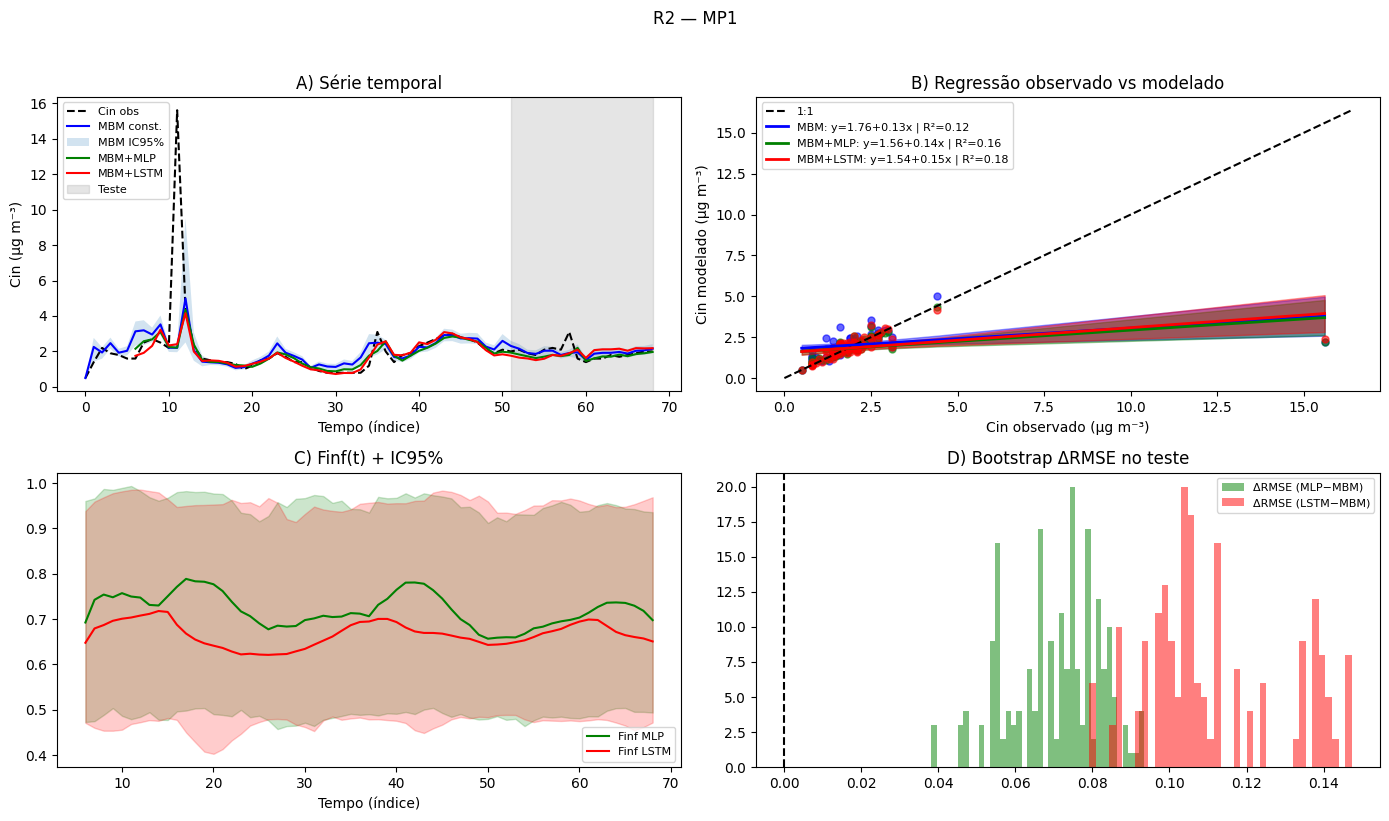

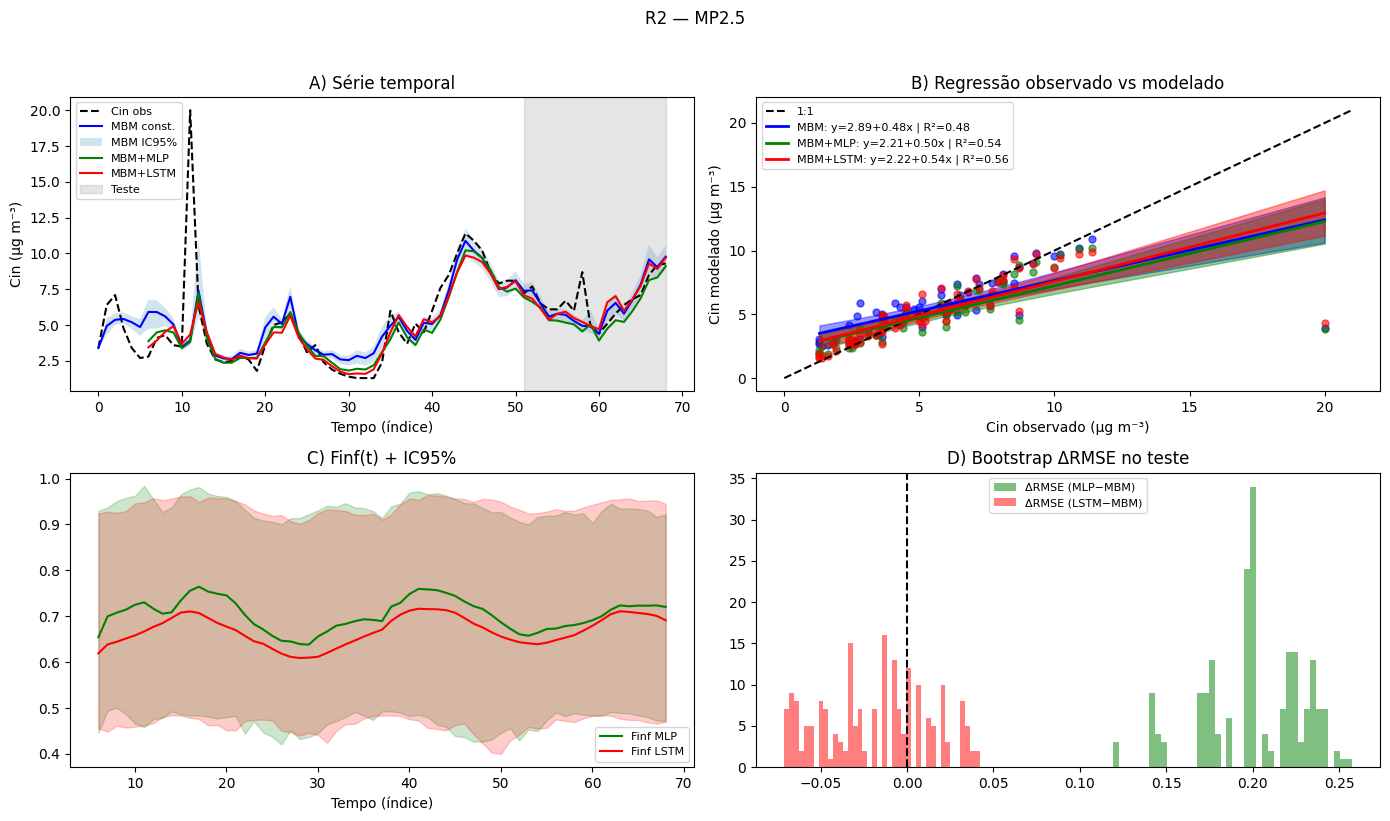

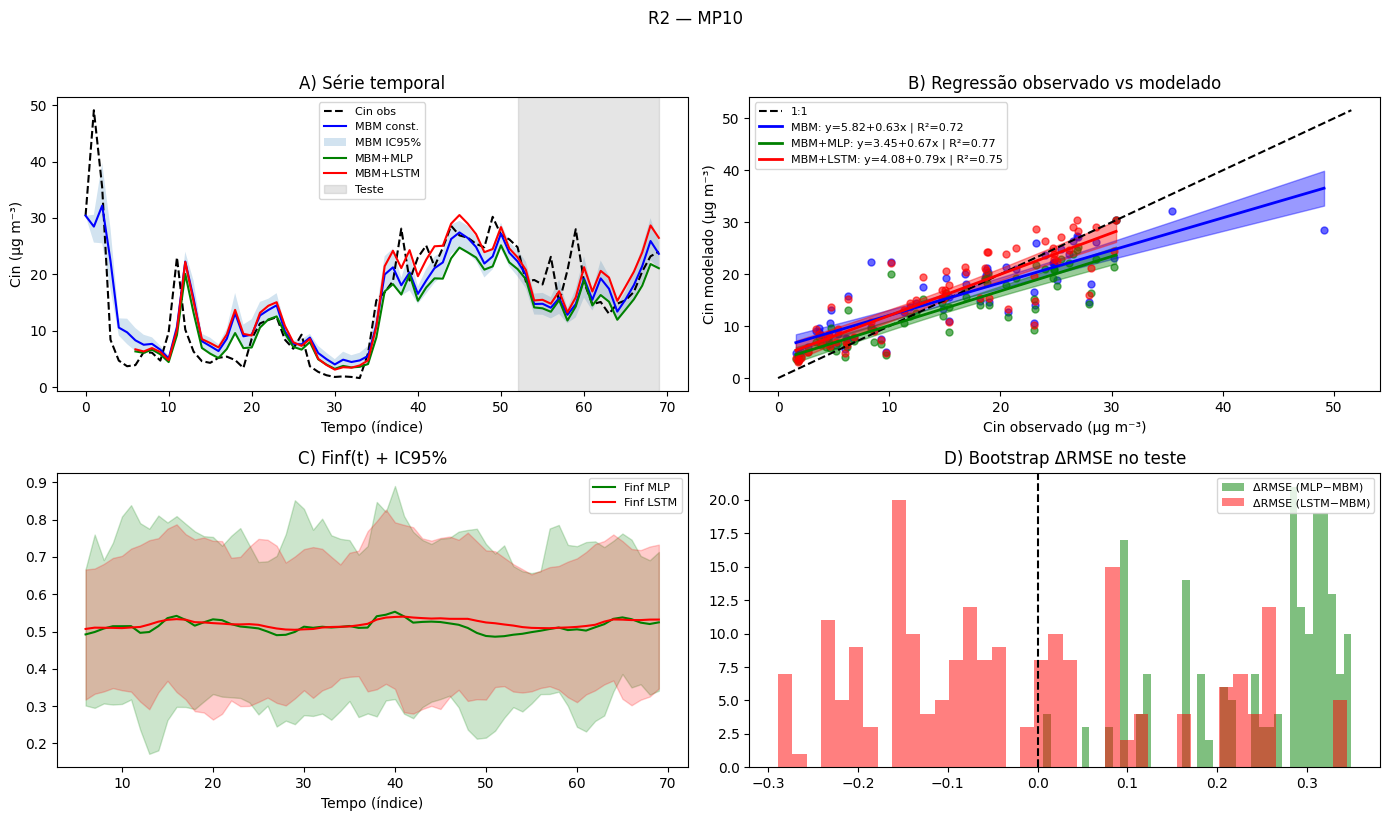

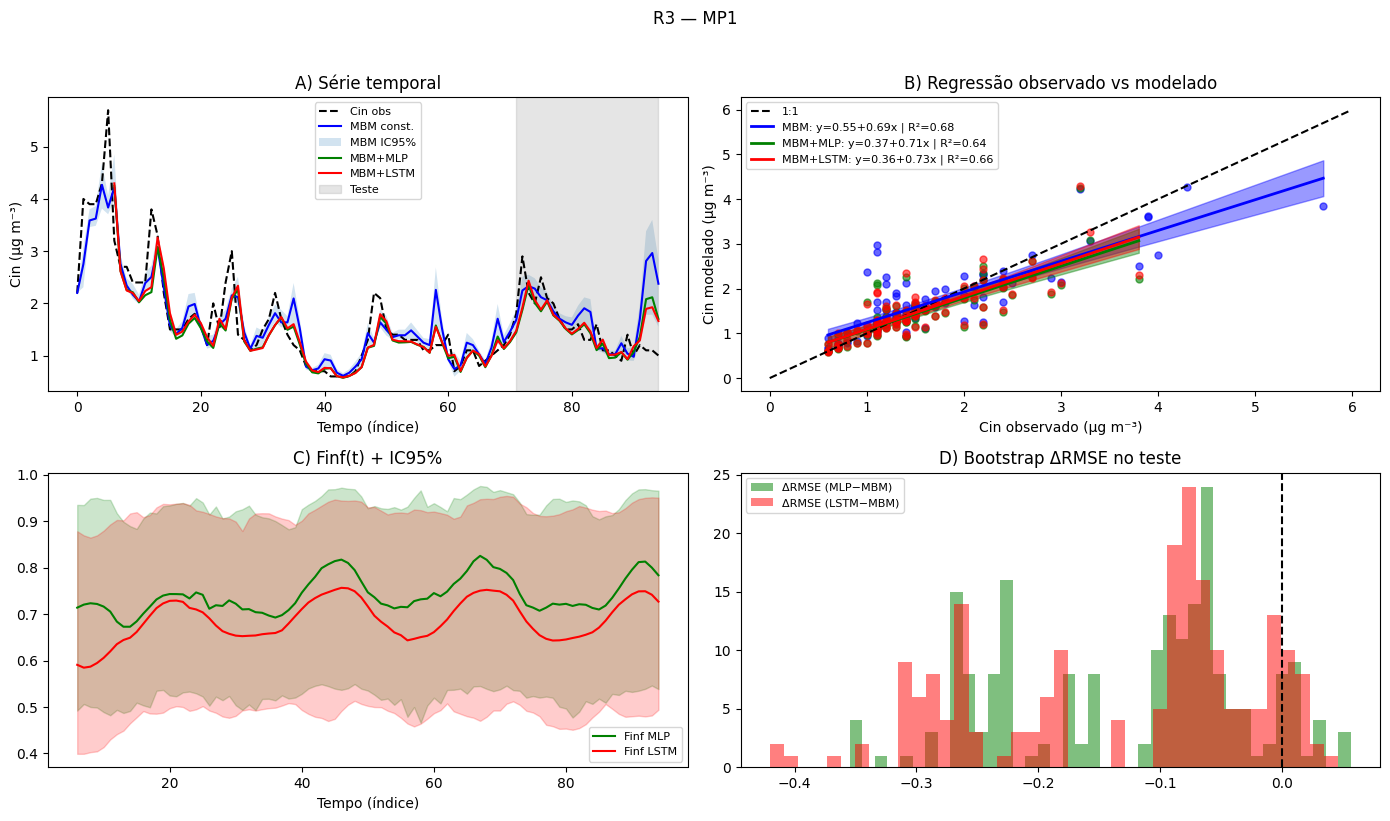

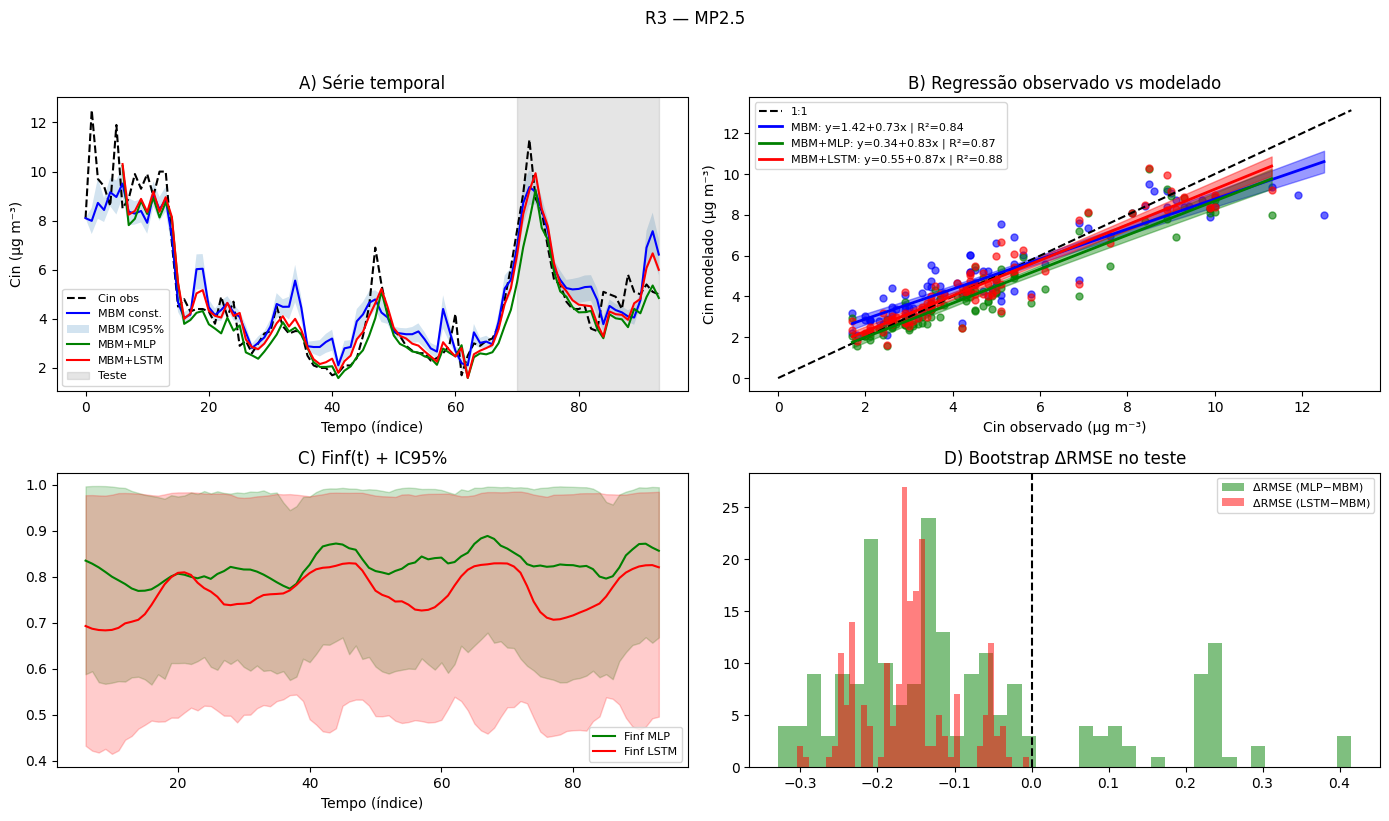

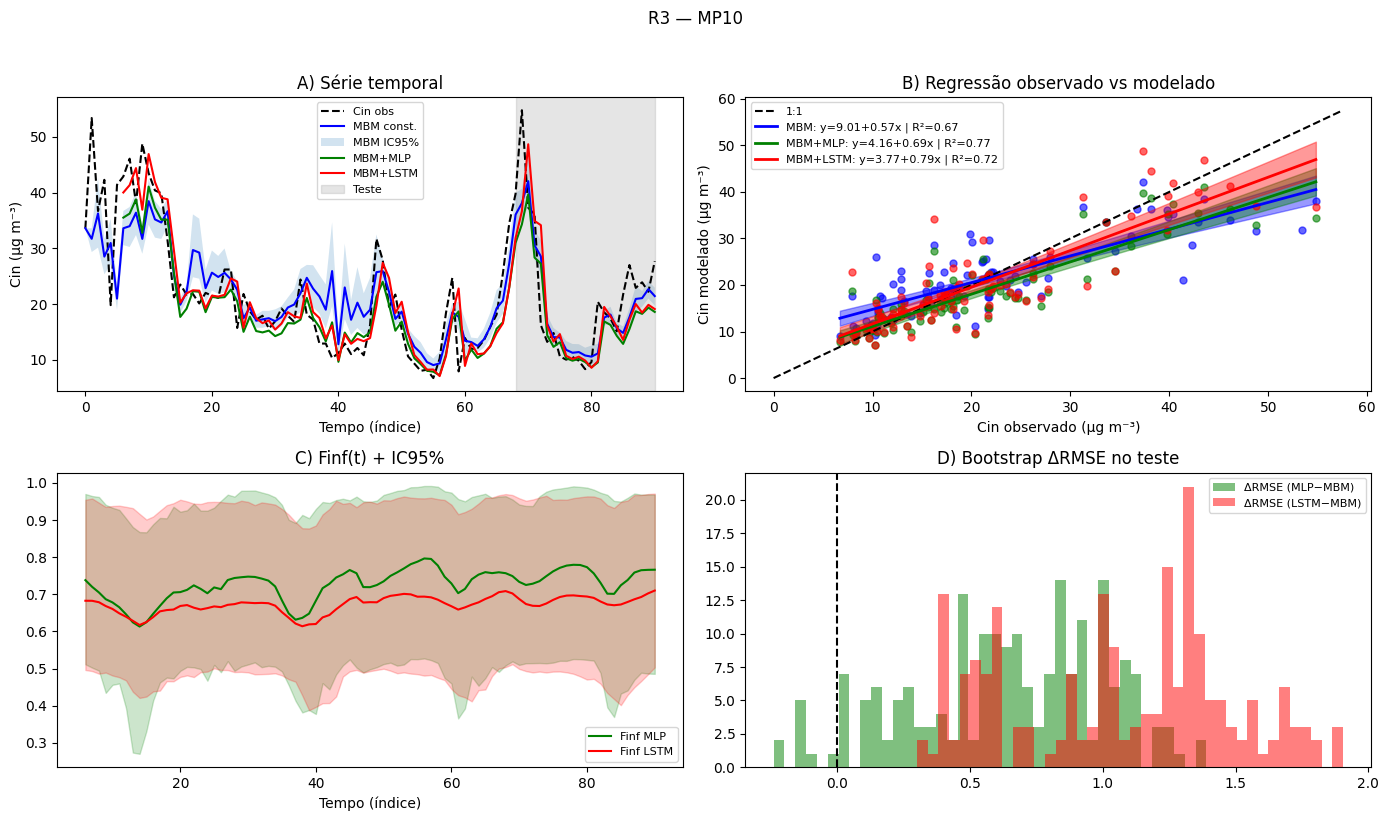

,casa,pm,pm_name,T,best_hp_lstm,best_hp_mlp,cv_lstm_outer,cv_mlp_outer,MBM_RMSE,MBM_R2,...,DM_MBM_MLP,p_MBM_MLP,DM_MLP_LSTM,p_MLP_LSTM,Finf_const,k_const,Finf_const_lo,Finf_const_hi,k_const_lo,k_const_hi
0,R2,MP1,MP1,69,"{'hidden': 32, 'num_layers': 2, 'dropout': 0.2...","{'hidden_sizes': (256, 128), 'dropout': 0.0, '...","[0.27575496262519816, 0.567191388251134, 0.050...","[0.33541860440373444, 0.5863271716228252, 0.06...",0.341403,0.070076,...,-1.358339,0.174356,-2.134715,0.032784,0.881858,1.414765,0.731674,1.000000,0.563524,2.727334
1,R2,MP2.5,MP2.5,69,"{'hidden': 32, 'num_layers': 2, 'dropout': 0.2...","{'hidden_sizes': (256, 128), 'dropout': 0.2, '...","[0.9044022735718303, 1.148077942898021, 0.2619...","[0.9320098695057276, 1.1519510610877264, 0.432...",1.046549,0.432006,...,-1.780891,0.074930,1.130936,0.258082,0.840041,1.662875,0.747435,0.912138,0.842837,2.816853
2,R2,MP10,MP10,70,"{'hidden': 96, 'num_layers': 2, 'dropout': 0.3...","{'hidden_sizes': (64, 32), 'dropout': 0.1, 'lr...","[1.4825126292918631, 4.9257660169118855, 4.024...","[1.584197978747261, 4.964764587896765, 3.25119...",4.763135,-0.358217,...,-1.283035,0.199480,0.017355,0.986154,0.612681,0.763244,0.491638,0.701345,0.365648,1.267924
3,R3,MP1,MP1,95,"{'hidden': 128, 'num_layers': 2, 'dropout': 0....","{'hidden_sizes': (128, 64), 'dropout': 0.3, 'l...","[0.3540799143251635, 0.27140299451124367, 0.18...","[0.3556702336579661, 0.2779370763522817, 0.197...",0.659614,-0.642818,...,1.663566,0.096199,1.858407,0.063111,0.769258,1.445600,0.651658,0.838726,0.440011,3.167718
4,R3,MP2.5,MP2.5,94,"{'hidden': 96, 'num_layers': 2, 'dropout': 0.3...","{'hidden_sizes': (64, 32), 'dropout': 0.1, 'lr...","[0.6395889368024251, 0.9805954042397019, 0.737...","[0.5402735769712396, 0.7595094510310588, 0.721...",1.102739,0.658376,...,-0.292624,0.769810,1.300198,0.193533,0.915755,1.695607,0.815387,0.985245,0.818240,3.024747
5,R3,MP10,MP10,91,"{'hidden': 96, 'num_layers': 2, 'dropout': 0.3...","{'hidden_sizes': (64, 32), 'dropout': 0.1, 'lr...","[3.0796458248729026, 4.535501882946551, 6.7281...","[3.075723746452134, 3.7863851030480777, 6.2738...",5.930115,0.731842,...,-2.239029,0.025154,-0.363064,0.716557,0.884473,0.667446,0.705059,1.000000,0.354259,1.230119


,pm,metric,mean,ci_low,ci_high
0,MP1,RMSE MBM,0.500509,0.349359,0.651658
1,MP1,RMSE MBM+MLP,0.418514,0.388075,0.448954
2,MP1,RMSE MBM+LSTM,0.431338,0.409590,0.453087
3,MP1,R² MBM,-0.286371,-0.624996,0.052253
4,MP1,R² MBM+MLP,0.020928,-0.181024,0.222879
5,MP1,R² MBM+LSTM,-0.138024,-0.620733,0.344684
6,MP1,ΔRMSE (MLP−MBM),-0.027480,-0.120337,0.065378
7,MP1,ΔRMSE (LSTM−MBM),-0.008500,-0.122245,0.105244
8,MP1,ΔRMSE (LSTM−MLP),0.009502,-0.018411,0.037415
9,MP2.5,RMSE MBM,1.074644,1.047954,1.101334


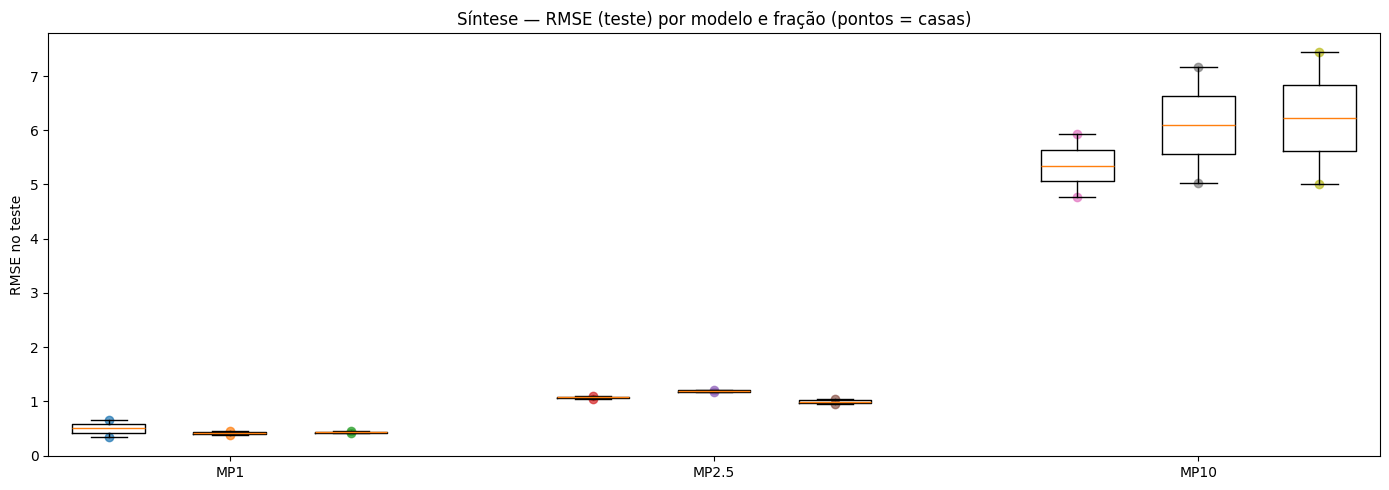

('outputs_v5\\figures\\FIG_SINTESE_RMSE_v5.png',
 'outputs_v5\\figures\\FIG_SINTESE_RMSE_v5.pdf')

In [28]:

# =========================
# 12) Execução em lote + tabelas para artigo
# =========================

all_rows=[]
details_store={}
all_granger=[]

for casa, fp in FILES.items():
    df = pd.read_excel(fp)
    for pm_name, (cin_col, cout_col) in PM_FRACTIONS.items():
        try:
            summary, detail = run_case(df, casa, pm_name, cin_col, cout_col, hour_col=HOUR_COL, extra_cols=EXTRA_COLS,
                                       dt=DT, seq_len=SEQ_LEN, block_size=BLOCK_SIZE)
            # garante chaves de identificação (robusto a mudanças dentro do run_case)
            summary['casa'] = casa
            summary['pm'] = pm_name
            summary['pm_name'] = pm_name
            all_rows.append(summary)
            details_store[(casa, pm_name)] = detail

            # figura por caso
            plot_case(detail, f"{casa} — {pm_name}", f"FIG_{casa.replace(' ','_')}_{pm_name.replace('.','p')}_v5")

            # salva correlações (tabela)
            corr_lstm = detail["corr_lstm"].copy(); corr_lstm["model"]="LSTM"; corr_lstm["casa"]=casa; corr_lstm["pm"]=pm_name
            corr_mlp  = detail["corr_mlp"].copy();  corr_mlp["model"]="MLP";  corr_mlp["casa"]=casa; corr_mlp["pm"]=pm_name
            corr = pd.concat([corr_lstm, corr_mlp], ignore_index=True)
            corr.to_csv(os.path.join(TABDIR, f"corr_{casa.replace(' ','_')}_{pm_name.replace('.','p')}_v5.csv"), index=False)

            # salva Granger (tabela)
            gr_lstm = detail.get("granger_lstm", pd.DataFrame()).copy(); gr_lstm["model"]="LSTM"; gr_lstm["casa"]=casa; gr_lstm["pm"]=pm_name
            gr_mlp  = detail.get("granger_mlp",  pd.DataFrame()).copy(); gr_mlp["model"]="MLP";  gr_mlp["casa"]=casa; gr_mlp["pm"]=pm_name
            gr = pd.concat([gr_lstm, gr_mlp], ignore_index=True) if (len(gr_lstm)+len(gr_mlp))>0 else pd.DataFrame()
            if len(gr)>0:
                gr.to_csv(os.path.join(TABDIR, f"granger_{casa.replace(' ','_')}_{pm_name.replace('.','p')}_v5.csv"), index=False)
                all_granger.append(gr)

        except Exception as e:
            print(f"Falha {casa} {pm_name}: {e}")

df_res = pd.DataFrame(all_rows)
if len(df_res)==0:
    raise RuntimeError('Nenhum caso foi processado com sucesso. Verifique as mensagens "Falha casa pm" acima.')
display(df_res)

# Tabela final (artigo): média ± IC95% entre casas por fração
def mean_ci(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x)==0:
        return np.nan, np.nan, np.nan
    mu = float(np.mean(x))
    lo = float(np.percentile(x, 2.5))
    hi = float(np.percentile(x, 97.5))
    return mu, lo, hi

rows=[]
pm_col = "pm" if "pm" in df_res.columns else ("pm_name" if "pm_name" in df_res.columns else None)
if pm_col is None:
    raise KeyError("Nenhuma coluna pm/pm_name encontrada em df_res")
for pm in df_res[pm_col].unique():
    d = df_res[df_res[pm_col]==pm]

    for metric, label in [("MBM_RMSE","RMSE MBM"), ("MLP_RMSE","RMSE MBM+MLP"), ("LSTM_RMSE","RMSE MBM+LSTM"),
                          ("MBM_R2","R² MBM"), ("MLP_R2","R² MBM+MLP"), ("LSTM_R2","R² MBM+LSTM"),
                          ("dRMSE_MLP_MBM_mean","ΔRMSE (MLP−MBM)"), ("dRMSE_LSTM_MBM_mean","ΔRMSE (LSTM−MBM)"), ("dRMSE_LSTM_MLP_mean","ΔRMSE (LSTM−MLP)")]:
        mu, lo, hi = mean_ci(d[metric].values)
        rows.append(dict(pm=pm, metric=label, mean=mu, ci_low=lo, ci_high=hi))

df_tab = pd.DataFrame(rows)
display(df_tab)

df_res.to_csv(os.path.join(TABDIR, "resultados_por_caso_v5.csv"), index=False)
if len(all_granger)>0:
    df_gr = pd.concat(all_granger, ignore_index=True)
    df_gr.to_csv(os.path.join(TABDIR, "granger_results_v5.csv"), index=False)
df_tab.to_csv(os.path.join(TABDIR, "tabela_final_artigo_v5.csv"), index=False)

# Markdown simples
md_lines = ["| Fração | Métrica | Média | IC95% |", "|---|---|---:|---:|"]
for _,r in df_tab.iterrows():
    md_lines.append(f"| {r['pm']} | {r['metric']} | {r['mean']:.4g} | [{r['ci_low']:.4g}, {r['ci_high']:.4g}] |")
with open(os.path.join(TABDIR, "tabela_final_artigo_v5.md"), "w", encoding="utf-8") as f:
    f.write("\n".join(md_lines))

# LaTeX (booktabs)
tex_lines = [
r"\begin{tabular}{llrr}",
r"\toprule",
r"Fração & Métrica & Média & IC95\% \\",
r"\midrule"
]
for _,r in df_tab.iterrows():
    tex_lines.append(f"{r['pm']} & {r['metric']} & {r['mean']:.4g} & [{r['ci_low']:.4g}, {r['ci_high']:.4g}] \\\\")
tex_lines += [r"\bottomrule", r"\end{tabular}"]
with open(os.path.join(TABDIR, "tabela_final_artigo_v5.tex"), "w", encoding="utf-8") as f:
    f.write("\n".join(tex_lines))

# Figura síntese
synthesis_figure(df_res)

[WARN] DETAILS_SHAPED não tem ('R1', 'cinPM1'). Pulando.


100%|██████████| 53/53 [00:05<00:00, 10.24it/s]


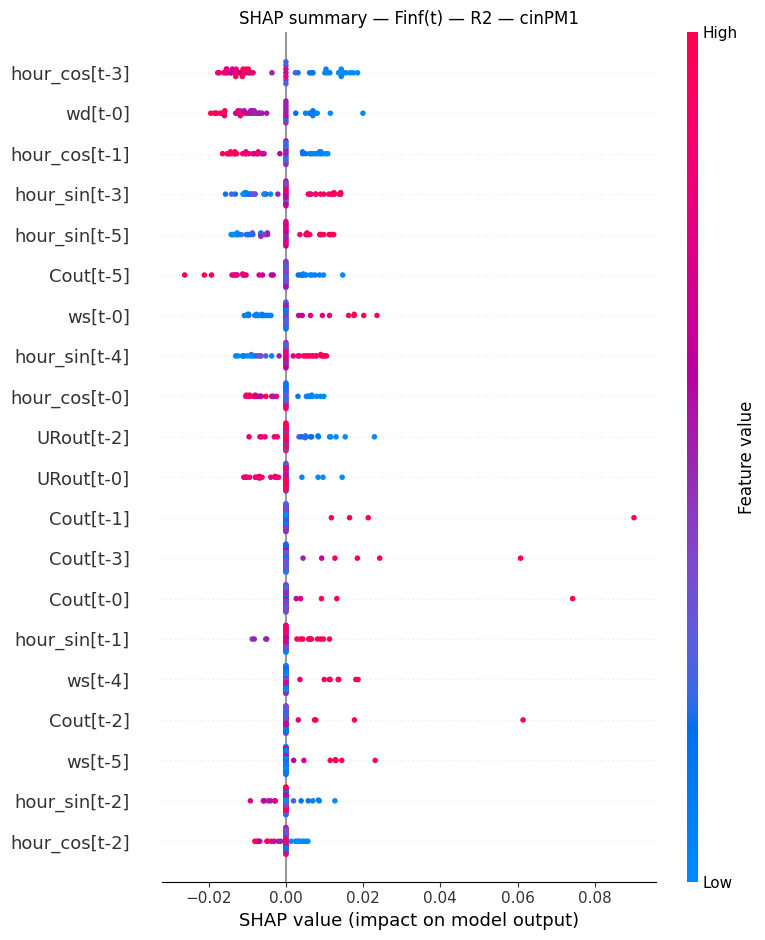

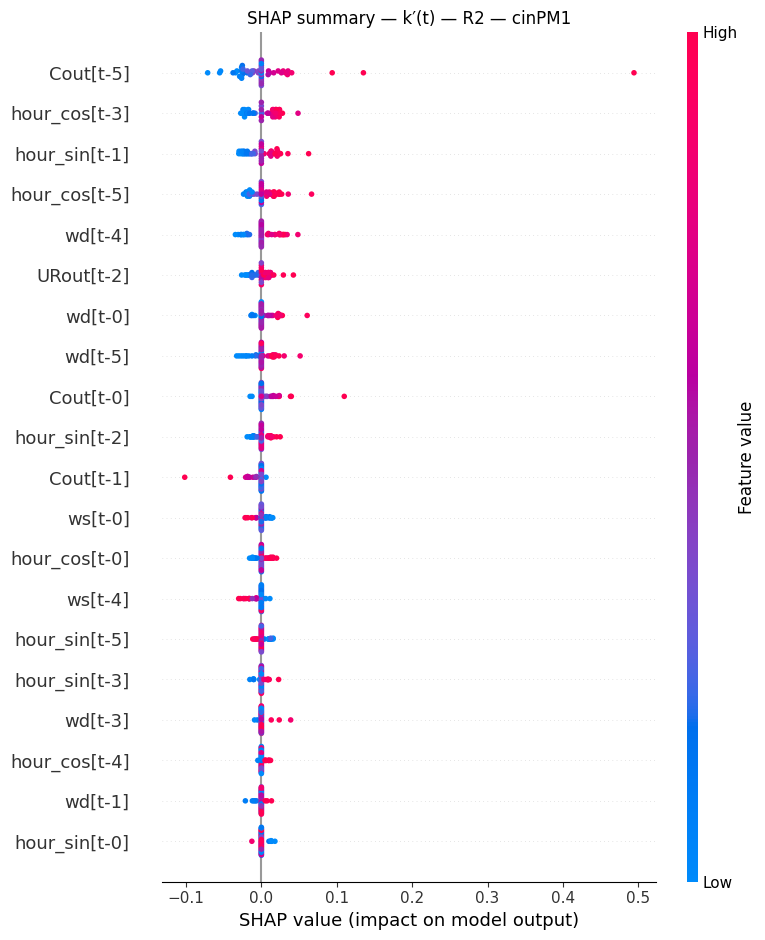

100%|██████████| 79/79 [00:06<00:00, 12.97it/s]


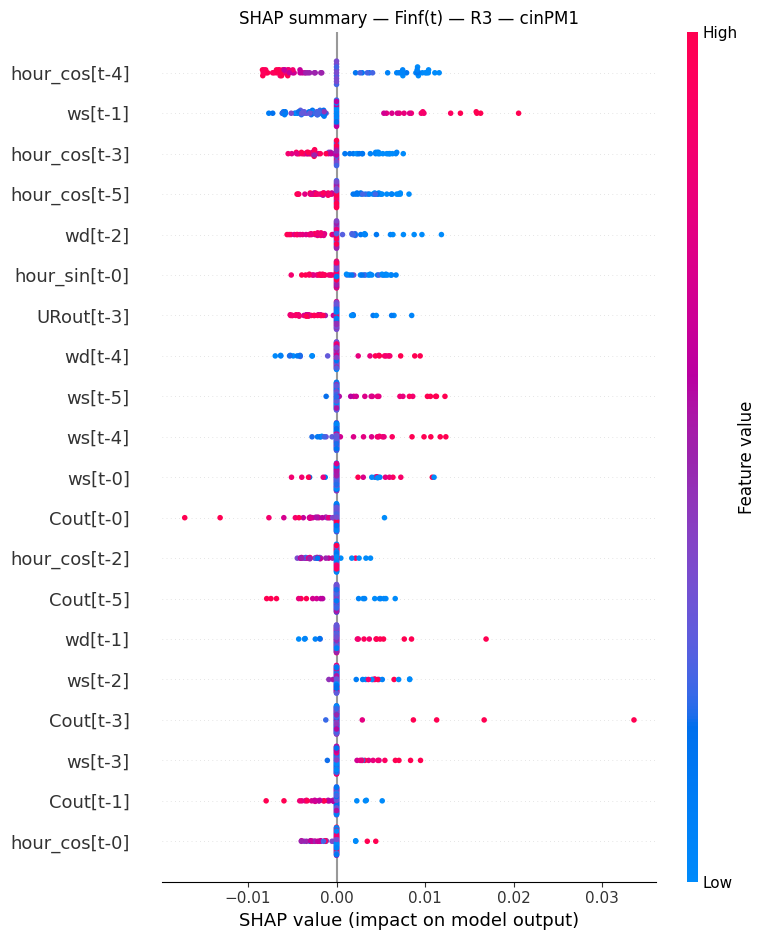

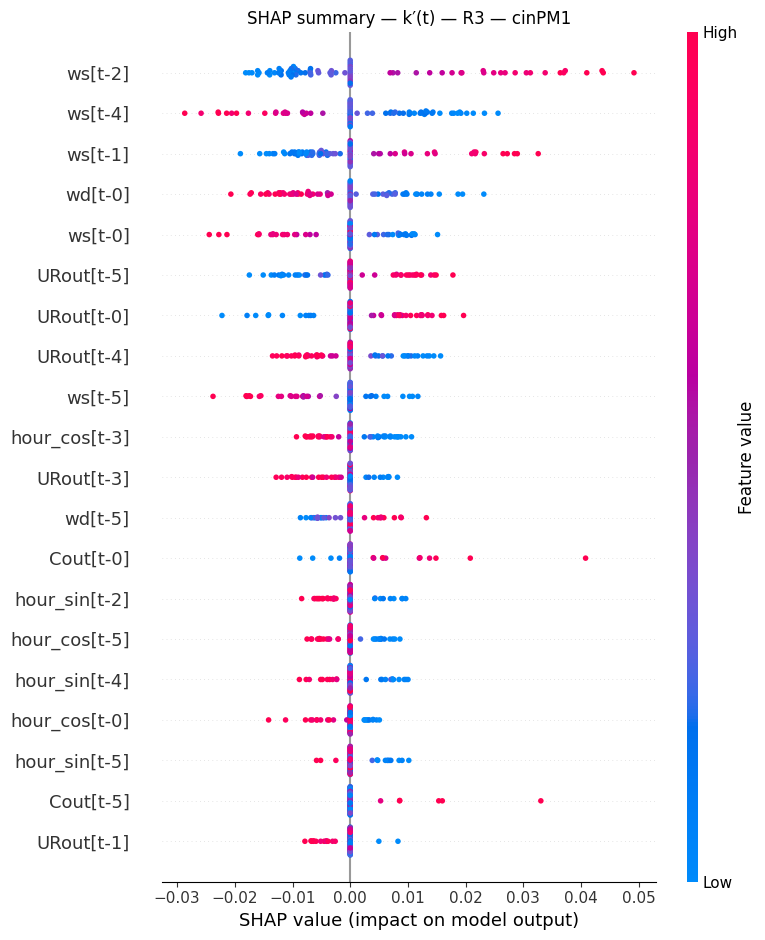

[WARN] DETAILS_SHAPED não tem ('R4', 'cinPM1'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R5', 'cinPM1'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R6', 'cinPM1'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R7', 'cinPM1'). Pulando.


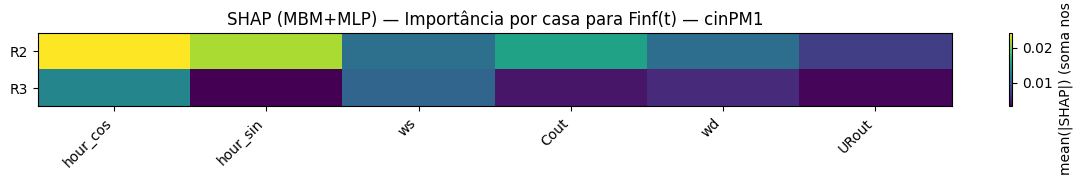

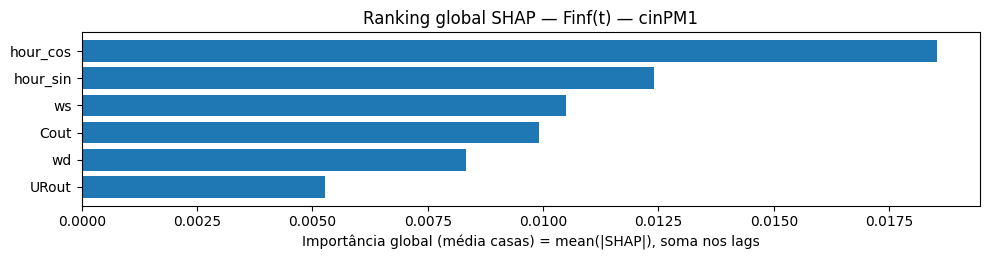

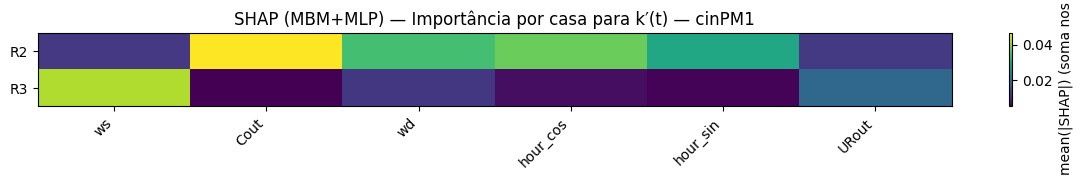

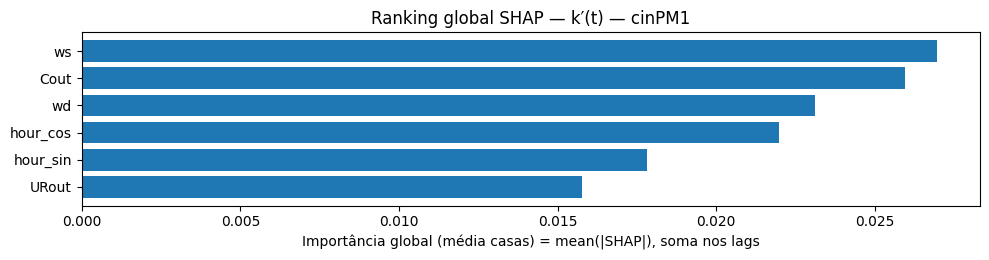

[WARN] DETAILS_SHAPED não tem ('R1', 'cinPM2.5'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R2', 'cinPM2.5'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R3', 'cinPM2.5'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R4', 'cinPM2.5'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R5', 'cinPM2.5'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R6', 'cinPM2.5'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R7', 'cinPM2.5'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R1', 'cinPM10'). Pulando.


100%|██████████| 54/54 [00:03<00:00, 15.07it/s]


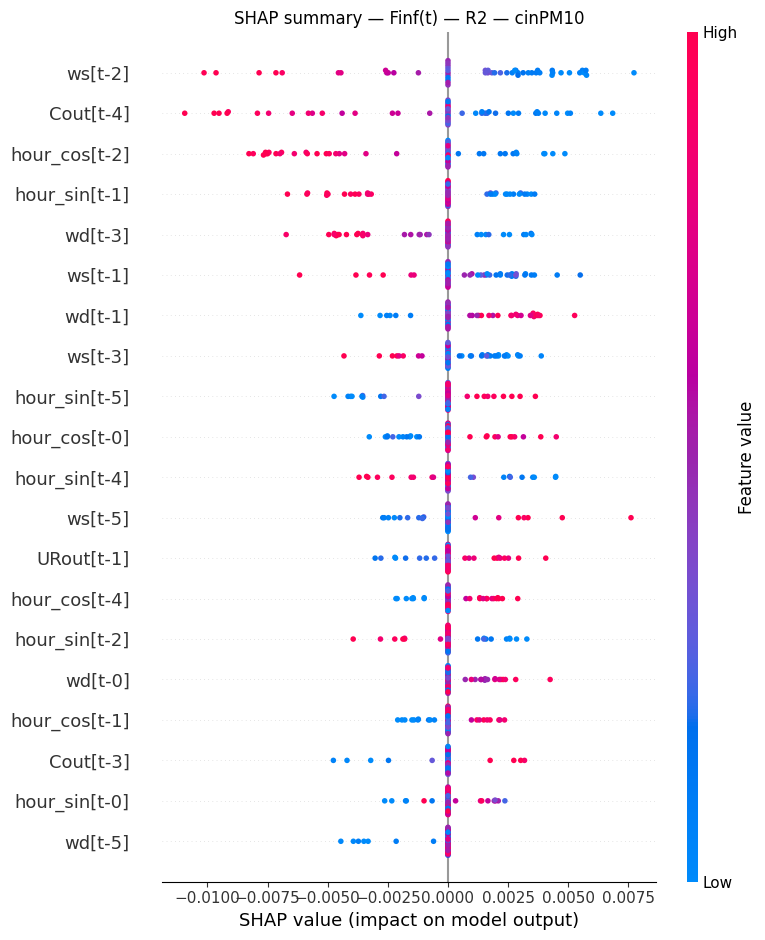

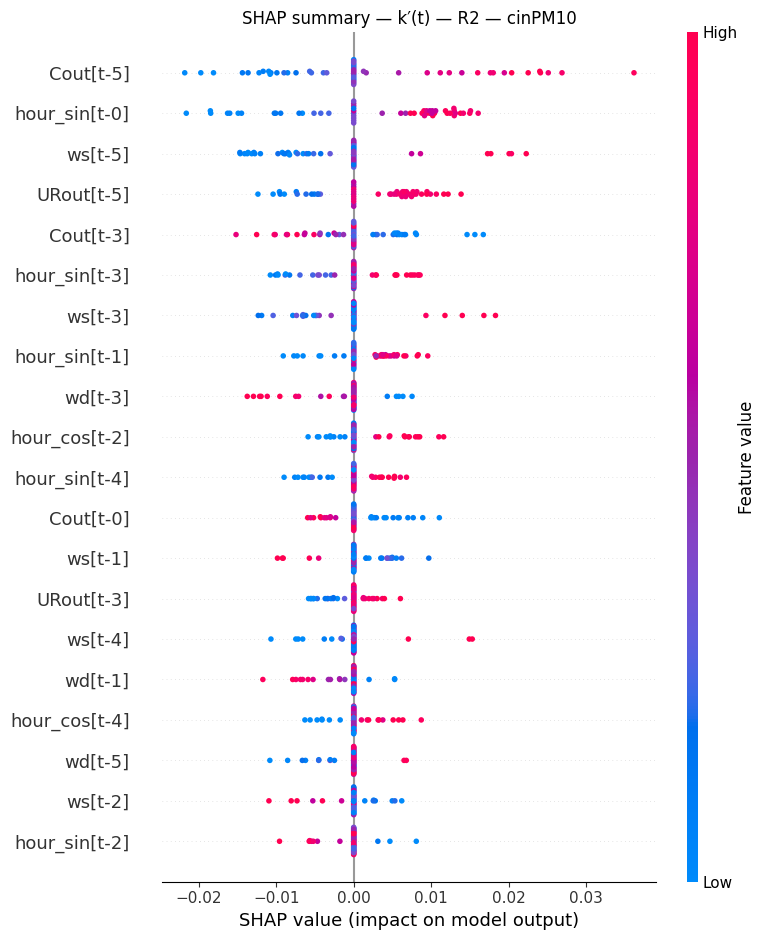

100%|██████████| 75/75 [00:05<00:00, 13.67it/s]


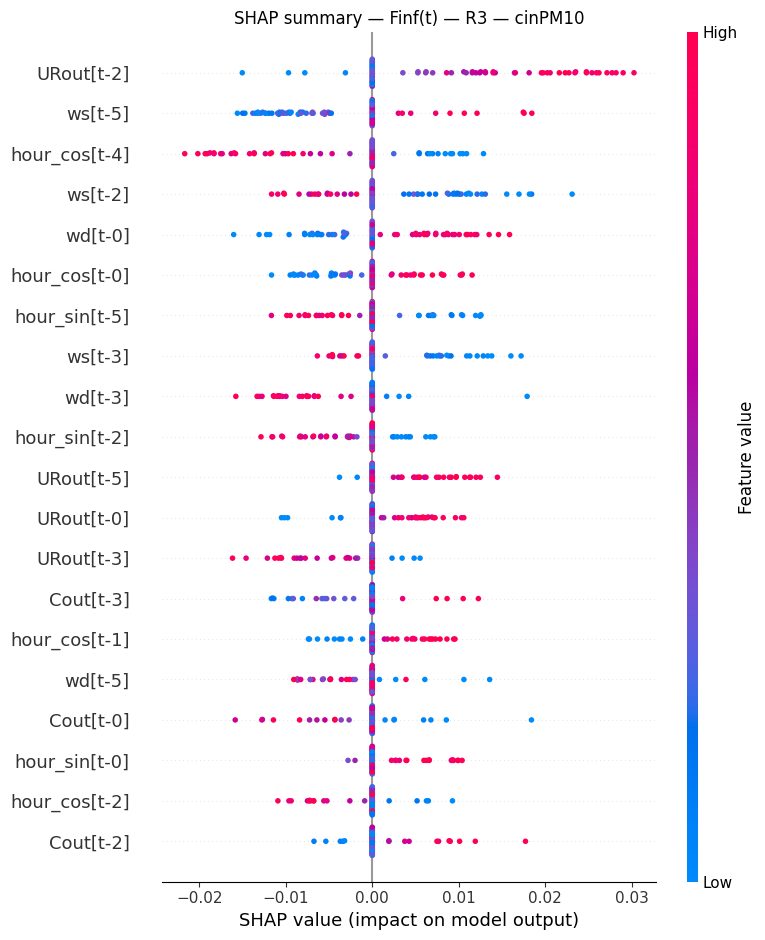

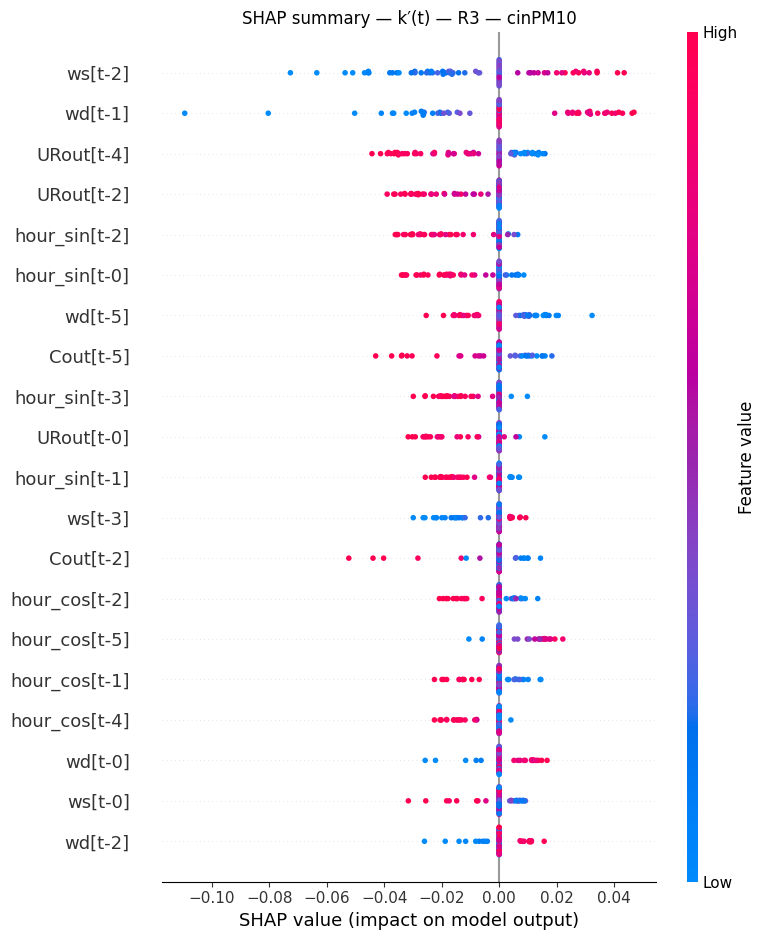

[WARN] DETAILS_SHAPED não tem ('R4', 'cinPM10'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R5', 'cinPM10'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R6', 'cinPM10'). Pulando.
[WARN] DETAILS_SHAPED não tem ('R7', 'cinPM10'). Pulando.


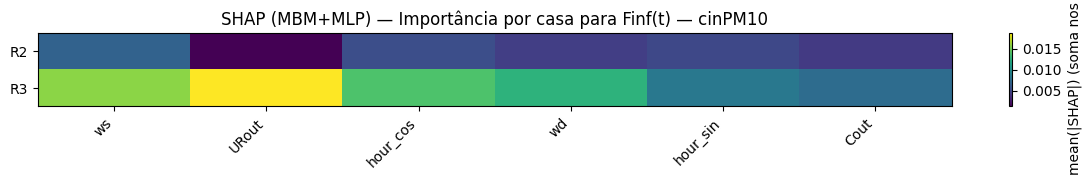

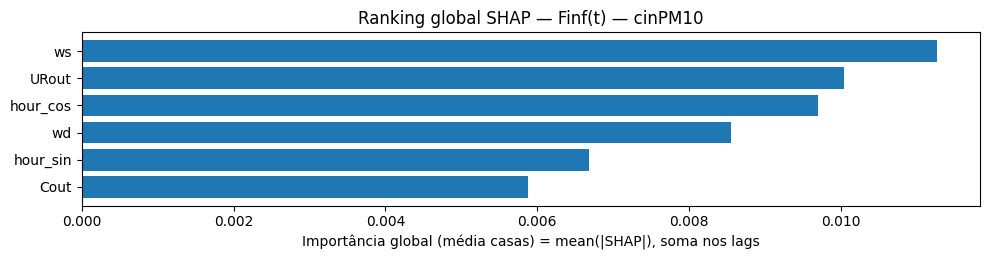

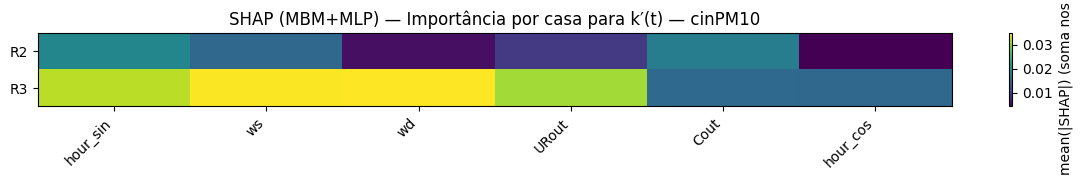

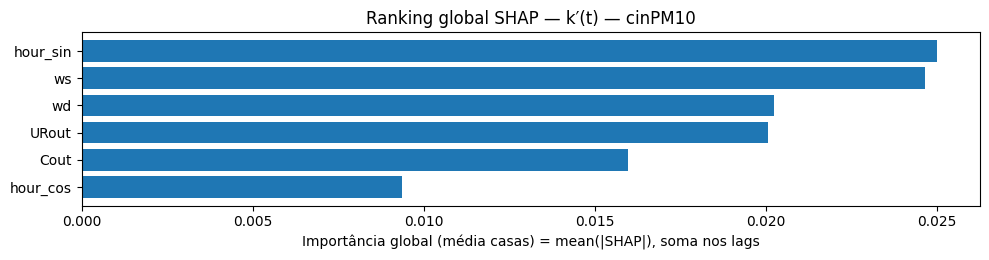

,frac,house,Finf_top10,k_top10
0,cinPM1,R2,"hour_cos, hour_sin, Cout, ws, wd, URout","Cout, hour_cos, wd, hour_sin, URout, ws"
1,cinPM1,R3,"hour_cos, ws, wd, Cout, URout, hour_sin","ws, URout, wd, hour_cos, hour_sin, Cout"
2,cinPM10,R2,"ws, hour_cos, hour_sin, wd, Cout, URout","hour_sin, Cout, ws, URout, wd, hour_cos"
3,cinPM10,R3,"URout, ws, hour_cos, wd, hour_sin, Cout","wd, ws, hour_sin, URout, Cout, hour_cos"



✅ SHAP completo! Arquivos salvos em: outputs_v5/shap


In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import torch

# =========================
# CONFIG
# =========================
SEQ_LEN = 6

# background e avaliação (KernelExplainer é pesado)
N_BG = 10        # 40–80 ok
N_EVAL = 200     # 150–400 ok
SEED = 2026

# quantas variáveis mostrar nos gráficos/tabelas
TOP_VARS = 15

# salvar outputs
OUTDIR = "outputs_v5/shap"
os.makedirs(OUTDIR, exist_ok=True)

# casas e frações
HOUSES = ["R1", "R2", "R3", "R4", "R5", "R6", "R7"]
FRACS = ["cinPM1", "cinPM2.5", "cinPM10"]


# =========================
# HELPERS
# =========================
def build_shap_dataset(X_s, seq_len=6):
    X_s = np.asarray(X_s, float)
    T, p = X_s.shape
    X_list = []
    for t in range(seq_len, T):
        X_list.append(X_s[t-seq_len:t].reshape(-1))
    return np.array(X_list, dtype=float)


def make_feature_names_with_lags(feat_names, seq_len=6):
    names = []
    for i in range(seq_len):
        lag = seq_len - 1 - i
        for nm in feat_names:
            names.append(f"{nm}[t-{lag}]")
    return names


def base_var(name):
    return name.split("[")[0] if "[" in name else name


def aggregate_abs_shap_by_basevar(shap_values, feature_names_flat):
    abs_mean = np.mean(np.abs(shap_values), axis=0)
    df = pd.DataFrame({"feature": feature_names_flat, "abs_mean": abs_mean})
    df["base"] = df["feature"].map(base_var)
    # soma das importâncias pelos lags
    return df.groupby("base")["abs_mean"].sum().sort_values(ascending=False)


def plot_heatmap_importance(df_house_var, title, top_vars=12, savepath=None):
    global_rank = df_house_var.mean(axis=0).sort_values(ascending=False)
    cols = list(global_rank.head(top_vars).index)
    mat = df_house_var[cols].values

    plt.figure(figsize=(12, 0.8 + 0.55*len(df_house_var)))
    plt.imshow(mat, aspect="auto")
    plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
    plt.yticks(range(len(df_house_var.index)), df_house_var.index)
    plt.colorbar(label="mean(|SHAP|) (soma nos lags)")
    plt.title(title)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300)
    plt.show()


def plot_global_bar(global_rank, title, top_vars=15, savepath=None):
    top = global_rank.head(top_vars)[::-1]
    plt.figure(figsize=(10, 0.6 + 0.35*len(top)))
    plt.barh(top.index, top.values)
    plt.title(title)
    plt.xlabel("Importância global (média casas) = mean(|SHAP|), soma nos lags")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300)
    plt.show()


# =========================
# WRAPPERS (MLP -> Finf/k)
# =========================
class MLPWrapperFinf:
    def __init__(self, model, seq_len):
        self.model = model
        self.seq_len = seq_len

    def __call__(self, X_flat):
        X_flat = np.asarray(X_flat, float)
        n = X_flat.shape[0]
        p = X_flat.shape[1] // self.seq_len
        X_seq = X_flat.reshape(n, self.seq_len, p)
        with torch.no_grad():
            xt = torch.tensor(X_seq, dtype=torch.float32)
            Finf, k = self.model(xt)
        return Finf.detach().cpu().numpy()

class MLPWrapperK:
    def __init__(self, model, seq_len):
        self.model = model
        self.seq_len = seq_len

    def __call__(self, X_flat):
        X_flat = np.asarray(X_flat, float)
        n = X_flat.shape[0]
        p = X_flat.shape[1] // self.seq_len
        X_seq = X_flat.reshape(n, self.seq_len, p)
        with torch.no_grad():
            xt = torch.tensor(X_seq, dtype=torch.float32)
            Finf, k = self.model(xt)
        return k.detach().cpu().numpy()


def shap_for_house(model_mlp, X_s, feat_names, seq_len=6, n_bg=60, n_eval=200, seed=2026):
    rng = np.random.default_rng(seed)
    X_flat = build_shap_dataset(X_s, seq_len=seq_len)
    if len(X_flat) < (n_bg + 10):
        raise ValueError(f"Série curta para SHAP com n_bg={n_bg}. T_windows={len(X_flat)}")

    idx = np.arange(len(X_flat))
    rng.shuffle(idx)
    bg_idx = idx[:min(n_bg, len(X_flat))]
    ev_idx = idx[min(n_bg, len(X_flat)):min(n_bg+n_eval, len(X_flat))]

    X_bg = X_flat[bg_idx]
    X_eval = X_flat[ev_idx]

    feat_flat = make_feature_names_with_lags(feat_names, seq_len=seq_len)

    # wrappers
    f_finf = MLPWrapperFinf(model_mlp, seq_len)
    f_k = MLPWrapperK(model_mlp, seq_len)

    # explainers
    expl_finf = shap.KernelExplainer(f_finf, X_bg)
    expl_k = shap.KernelExplainer(f_k, X_bg)

    shap_finf = expl_finf.shap_values(X_eval)
    shap_k = expl_k.shap_values(X_eval)

    # KernelExplainer às vezes retorna lista
    if isinstance(shap_finf, list):
        shap_finf = shap_finf[0]
    if isinstance(shap_k, list):
        shap_k = shap_k[0]

    return shap_finf, shap_k, X_eval, feat_flat


# =========================
# MAIN LOOP
# =========================
all_outputs = []

for frac in FRACS:
    house_rank_finf = {}
    house_rank_k = {}

    for house in HOUSES:
        key = (house, frac)
        if key not in DETAILS_SHAPED:
            print(f"[WARN] DETAILS_SHAPED não tem {key}. Pulando.")
            continue

        obj = DETAILS_SHAPED[key]
        model_mlp = obj["model_mlp"]
        X_s = obj["X_s"]
        feat_names = obj["feat_names"]

        # SHAP por casa
        shap_finf, shap_k, X_eval, feat_flat = shap_for_house(
            model_mlp=model_mlp,
            X_s=X_s,
            feat_names=feat_names,
            seq_len=SEQ_LEN,
            n_bg=N_BG,
            n_eval=N_EVAL,
            seed=SEED
        )

        # agregações por variável base (soma nos lags)
        rank_finf = aggregate_abs_shap_by_basevar(shap_finf, feat_flat)
        rank_k = aggregate_abs_shap_by_basevar(shap_k, feat_flat)

        house_rank_finf[house] = rank_finf
        house_rank_k[house] = rank_k

        # salvar tabelas por casa
        df_house = pd.DataFrame({
            "base_var": rank_finf.index,
            "Finf_importance": rank_finf.values
        })
        df_house["k_importance"] = rank_k.reindex(df_house["base_var"]).fillna(0).values
        df_house.to_csv(f"{OUTDIR}/shap_{house}_{frac}_basevar.csv", index=False)

        # opcional: summary plots por casa (Finf/k)
        # (deixe ligado se quiser figures individuais)
        try:
            plt.figure()
            shap.summary_plot(shap_finf, X_eval, feature_names=feat_flat, show=False)
            plt.title(f"SHAP summary — Finf(t) — {house} — {frac}")
            plt.tight_layout()
            plt.savefig(f"{OUTDIR}/shap_summary_Finf_{house}_{frac}.png", dpi=300)
            plt.show()

            plt.figure()
            shap.summary_plot(shap_k, X_eval, feature_names=feat_flat, show=False)
            plt.title(f"SHAP summary — k′(t) — {house} — {frac}")
            plt.tight_layout()
            plt.savefig(f"{OUTDIR}/shap_summary_k_{house}_{frac}.png", dpi=300)
            plt.show()
        except Exception as e:
            print(f"[WARN] Falha summary_plot {house}-{frac}: {e}")

        # armazenar top-variáveis (para tabela-resumo)
        all_outputs.append({
            "frac": frac,
            "house": house,
            "Finf_top10": ", ".join(rank_finf.head(10).index.tolist()),
            "k_top10": ", ".join(rank_k.head(10).index.tolist())
        })

    # combinar (houses x vars)
    if len(house_rank_finf) == 0:
        continue

    df_finf_house_var = pd.DataFrame(house_rank_finf).fillna(0.0).T  # houses x vars
    df_k_house_var = pd.DataFrame(house_rank_k).fillna(0.0).T

    finf_global = df_finf_house_var.mean(axis=0).sort_values(ascending=False)
    k_global = df_k_house_var.mean(axis=0).sort_values(ascending=False)

    # salvar globais
    df_finf_house_var.to_csv(f"{OUTDIR}/shap_house_importance_Finf_{frac}.csv", index=True)
    df_k_house_var.to_csv(f"{OUTDIR}/shap_house_importance_k_{frac}.csv", index=True)
    finf_global.to_csv(f"{OUTDIR}/shap_global_rank_Finf_{frac}.csv")
    k_global.to_csv(f"{OUTDIR}/shap_global_rank_k_{frac}.csv")

    # figuras comparativas todas casas
    plot_heatmap_importance(
        df_finf_house_var,
        title=f"SHAP (MBM+MLP) — Importância por casa para Finf(t) — {frac}",
        top_vars=TOP_VARS,
        savepath=f"{OUTDIR}/HEATMAP_Finf_{frac}.png"
    )
    plot_global_bar(
        finf_global,
        title=f"Ranking global SHAP — Finf(t) — {frac}",
        top_vars=TOP_VARS,
        savepath=f"{OUTDIR}/RANK_GLOBAL_Finf_{frac}.png"
    )

    plot_heatmap_importance(
        df_k_house_var,
        title=f"SHAP (MBM+MLP) — Importância por casa para k′(t) — {frac}",
        top_vars=TOP_VARS,
        savepath=f"{OUTDIR}/HEATMAP_k_{frac}.png"
    )
    plot_global_bar(
        k_global,
        title=f"Ranking global SHAP — k′(t) — {frac}",
        top_vars=TOP_VARS,
        savepath=f"{OUTDIR}/RANK_GLOBAL_k_{frac}.png"
    )

# tabela resumo top-variáveis por casa
df_top = pd.DataFrame(all_outputs)
df_top.to_csv(f"{OUTDIR}/shap_top_vars_by_house_all_fracs.csv", index=False)
display(df_top)

print(f"\n✅ SHAP completo! Arquivos salvos em: {OUTDIR}")

## Seção metodológica (texto pronto)

### Modelo mecanicista (MBM)
Adotou-se um modelo de balanço de massa discreto em passo horário (Δt = 1 h) para descrever a dinâmica da concentração interna de material particulado (Cin) em função da concentração externa (Cout). O modelo assume mistura perfeita e representa, de forma agregada, os processos de infiltração e remoção/depósito por um fator de infiltração Finf e uma taxa efetiva de remoção k′. A forma recursiva utilizada foi:

\[
\hat C_{in}(t)= C_{in}(t-1) e^{-k'\Delta t} + F_{inf} \, C_{out}(t)\, (1-e^{-k'\Delta t}).
\]

Os parâmetros constantes (Finf, k′) foram estimados por ajuste linear do modelo discreto e incertezas foram quantificadas via **moving block bootstrap** (block_size=6), utilizando apenas pontos classificados como de origem externa.

### Pré-processamento: outliers e censura
Antes da modelagem, valores extremos em Cout(t) foram substituídos por média local em janela móvel, com detecção robusta baseada em mediana e MAD. Em seguida, foi aplicada censura em Cin(t) para remover pontos com forte evidência de emissão interna, mantendo para calibração apenas instantes em que Cout(t) não é substancialmente inferior a Cin(t) (razão controlada por limiar), resultando em uma série censurada usada para treinamento e estimação.

### Modelos híbridos físicos-informados (MBM + rede)
Para incorporar variabilidade temporal dos parâmetros, foram propostos modelos híbridos em que uma rede neural estima **parâmetros variantes no tempo** Finf(t) e k′(t), enquanto a equação do balanço de massa atua como **camada de saída**. Em cada passo temporal, a rede recebe uma janela de comprimento seq_len=6 de preditores (incluindo Cout e variáveis meteorológicas/operacionais) e produz Finf(t) e k′(t) restringidos a domínios físicos via funções de ativação (sigmoid para Finf em [0,1] e softplus para k′≥0). A predição final de Cin(t) é obtida pela própria equação do MBM, garantindo consistência física.

Dois estimadores foram comparados sob o mesmo conjunto de entradas e janela temporal: (i) **LSTM**, para modelar dependências sequenciais, e (ii) **MLP** com entrada achatada (flatten) da mesma janela, como controle arquitetural. Ambos foram treinados minimizando o erro quadrático entre Cin(t) observado e Cin(t) modelado pelo MBM, com early stopping.

### Quantificação de incertezas e avaliação estatística
Intervalos de confiança de Finf(t), k′(t) e das trajetórias de Cin(t) foram obtidos por bootstrap em blocos com re-treinamento (n=200). A comparação de desempenho no conjunto de teste foi conduzida via bootstrap por blocos de \(\Delta RMSE\) e \(\Delta R^2\) e pelo teste de **Diebold–Mariano** (loss quadrática), incluindo a comparação direta **MLP vs LSTM**.

### Análise física
As séries estimadas Finf(t) e k′(t) foram analisadas quanto à associação com variáveis meteorológicas (umidade, vento, temperatura) por correlação de Spearman, incluindo análise com defasagens (lags até ±6 h), permitindo investigar relações temporais entre condições externas e os parâmetros de infiltração/remoção.
